In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cvxpy as cp
from sklearn.preprocessing import StandardScaler

In [ ]:
# Font for the plots
plt.rcParams['font.family'] = 'Avenir' 

DATA PREP 

In [9]:
# Load Mystery Allocation 1 (MA1) and set date as index
df_myst1 = pd.read_csv('Mystery Allocation 1.csv', header = None, names = ['Date', 'MA1']).set_index('Date')
df_myst1.index.name = None

# Load Mystery Allocation 2 (MA2) and set date as index
df_myst2 = pd.read_csv('Mystery Allocation 2.csv', header = None, names = ['Date', 'MA2']).set_index('Date')
df_myst2.index.name = None

# Join Mystery Allocations into one df on date
df_myst = df_myst1.join(df_myst2, how = 'inner')

# Format date index
df_myst.index = pd.to_datetime(df_myst.index, format="%d/%m/%Y")

df_myst.head()

,MA1,MA2
2019-01-01,100.000000,100.000000
2019-01-02,99.793394,99.606395
2019-01-03,98.479815,98.154552
2019-01-04,100.323356,100.950590
2019-01-07,100.917806,101.682693


In [10]:
# Load Anonymized ETFs data, drop empty 1st row and set date as index
df_etf = pd.read_csv('Anonymized ETFs.csv').drop(index = 0).set_index('Unnamed: 0')

# Format date index
df_etf.index = pd.to_datetime(df_etf.index, format="%d/%m/%Y")
df_etf.index.name = None

df_etf.head()

,ETF 1,ETF 2,ETF 3,ETF 4,ETF 5,ETF 6,ETF 7,ETF 8,ETF 9,ETF 10,...,ETF 96,ETF 97,ETF 98,ETF 99,ETF 100,ETF 101,ETF 102,ETF 103,ETF 104,ETF 105
2019-01-01,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,...,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
2019-01-02,100.127206,99.852703,98.988669,99.748783,100.090752,99.570627,100.204090,100.304926,100.806104,100.097658,...,98.605128,100.000000,99.492141,100.116734,100.000000,99.907320,98.171549,100.084769,99.771562,99.806328
2019-01-03,97.666622,98.379419,98.364879,98.406725,99.482257,97.222366,100.112381,100.895231,98.005089,100.519441,...,98.450142,100.000000,99.489749,99.016393,100.435572,97.467026,97.010214,100.485704,98.571873,97.942594
2019-01-04,101.019896,101.087119,99.898710,100.927003,101.633879,100.727186,99.800134,100.070368,101.214655,101.099655,...,100.898392,98.408971,101.366516,100.669668,102.126721,100.927780,98.317550,101.058468,101.463870,100.945457
2019-01-07,101.728194,101.914159,101.220592,101.829341,101.239553,101.492714,99.675080,101.032056,101.461918,101.681016,...,101.816486,101.241191,101.628816,101.187201,101.265259,101.550176,99.910418,101.640396,101.479410,101.379317


In [11]:
# Load main data, drop empty 1st row and set date as index
df_main = pd.read_csv('Main Asset Classes.csv', header = 4).drop(index = 0).set_index('Unnamed: 0')

# Format date index
df_main.index = pd.to_datetime(df_main.index, format="%d/%m/%Y")
df_main.index.name = None

df_main.head()

,S&P 500,Nasdaq 100,US Small Caps,Euro Stoxx 50,UK FTSE,MSCI EM,Japan,US IG,US HY,EU IG,EU HY,EM Bond,Gold,Commodity
2018-01-01,4672.65,7256.87,7554.1651,7048.52,6519.85,521.047,35413.76,282.4644,269.1327,226.5210,192.4179,551.774,323.6981,179.9572
2018-01-02,4711.60,7387.98,7625.7417,7020.80,6486.20,530.304,35413.76,280.7632,269.4638,226.4472,192.5863,551.634,325.4313,180.4815
2018-01-03,4741.75,7461.12,7638.4702,7060.42,6505.71,533.125,35413.76,281.4011,270.2244,226.6925,192.8904,552.930,326.0377,180.8937
2018-01-04,4761.55,7472.49,7654.2279,7179.11,6527.28,536.880,36567.09,281.2786,270.9258,226.7588,193.1619,554.020,326.8173,180.8199
2018-01-05,4795.03,7550.47,7675.4522,7257.05,6551.31,540.695,36890.97,280.8513,271.2983,226.9667,193.2546,554.859,327.0035,179.4927


In [12]:
# Show data range across datasets
print('Date range for anonymised ETFs:')
print(df_etf.index.min())
print(df_etf.index.max())

print('\n')
print('Date range for main assets:')
print(df_main.index.min())
print(df_main.index.max())

Date range for anonymised ETFs:
2019-01-01 00:00:00
2024-05-20 00:00:00


Date range for main assets:
2018-01-01 00:00:00
2024-05-22 00:00:00


In [13]:
# Align time indices for the same period
df_etf_aligned, df_main_aligned = df_etf.align(df_main, 'inner', axis=0)
df_myst_aligned, df_main_aligned = df_myst.align(df_main, 'inner', axis=0)

In [14]:
# Check for missing data
print('NaNs in ETF Data Frame:', df_etf_aligned.isna().sum().max())
print('NaNs in Asset Data Frame:', df_main_aligned.isna().sum().max())
print('NaNs in Myster Allocation:', df_myst_aligned.isna().sum().max())

NaNs in ETF Data Frame: 0
NaNs in Asset Data Frame: 0
NaNs in Myster Allocation: 0


EXPLORATORY DATA ANALYSIS 


Z-Scores for main asset prices

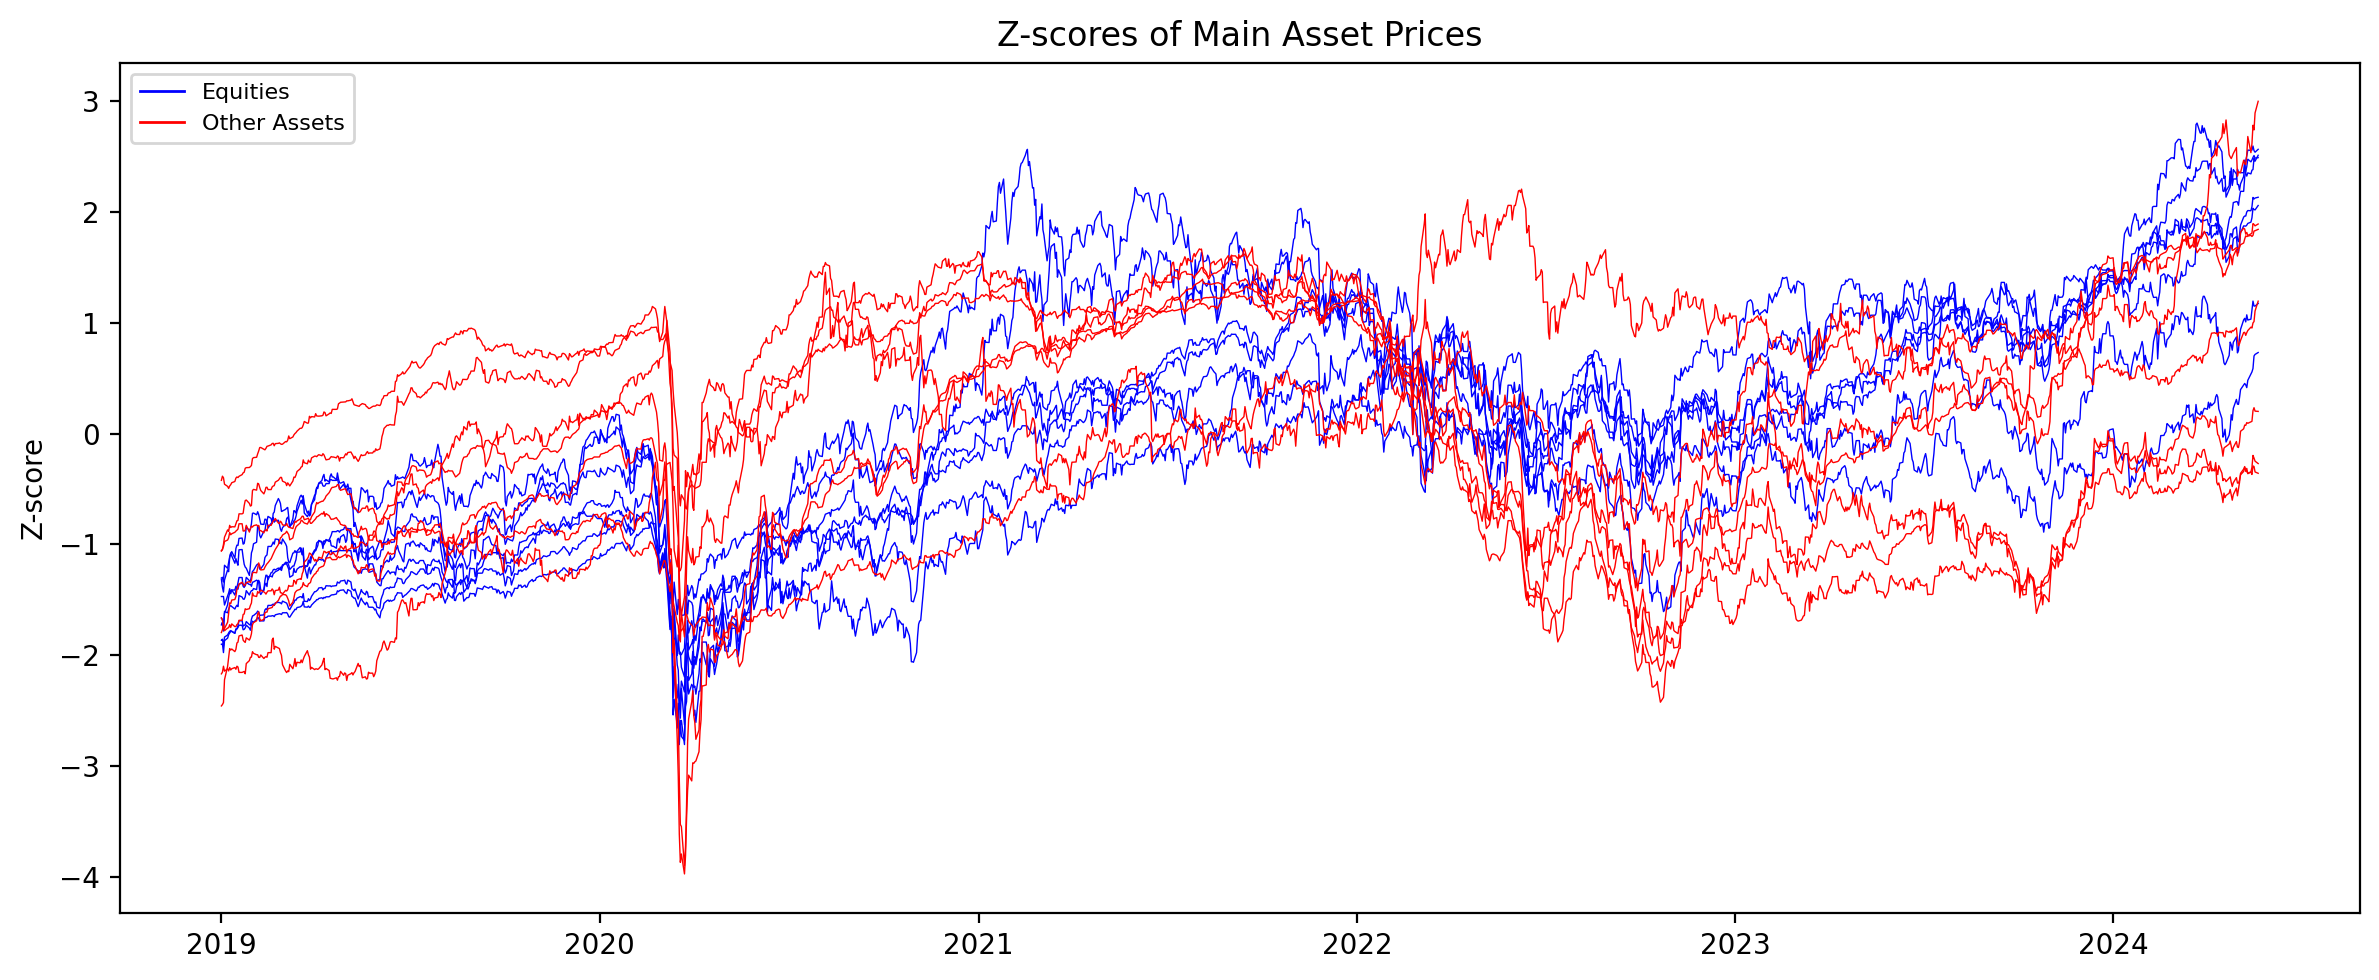

In [15]:
scaler = StandardScaler()

# Normalise price data for comparison
df_zscores = pd.DataFrame(scaler.fit_transform(df_main_aligned),
                          columns=df_main.columns,
                          index=df_main_aligned.index)

# Define broad asset classes for comparison
equities = ['S&P 500', 'Nasdaq 100', 'US Small Caps','Euro Stoxx 50', 'UK FTSE','MSCI EM', 'Japan ']
others = list(set(df_main_aligned.columns) - set(equities))

# Plot
plt.figure(figsize=(12,5), dpi=200)
plt.plot(df_zscores[equities], color = 'blue', linewidth=0.5)  
plt.plot(df_zscores[others], color = 'red', linewidth=0.5)

plt.title("Z-scores of Main Asset Prices",fontsize=12)
plt.ylabel("Z-score")

from matplotlib.lines import Line2D
custom_legend = [
    Line2D([0], [0], color='blue', lw=1, label='Equities'),
    Line2D([0], [0], color='red', lw=1, label='Other Assets')]

plt.legend(handles=custom_legend, loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

Z-scores for anonymised ETFs

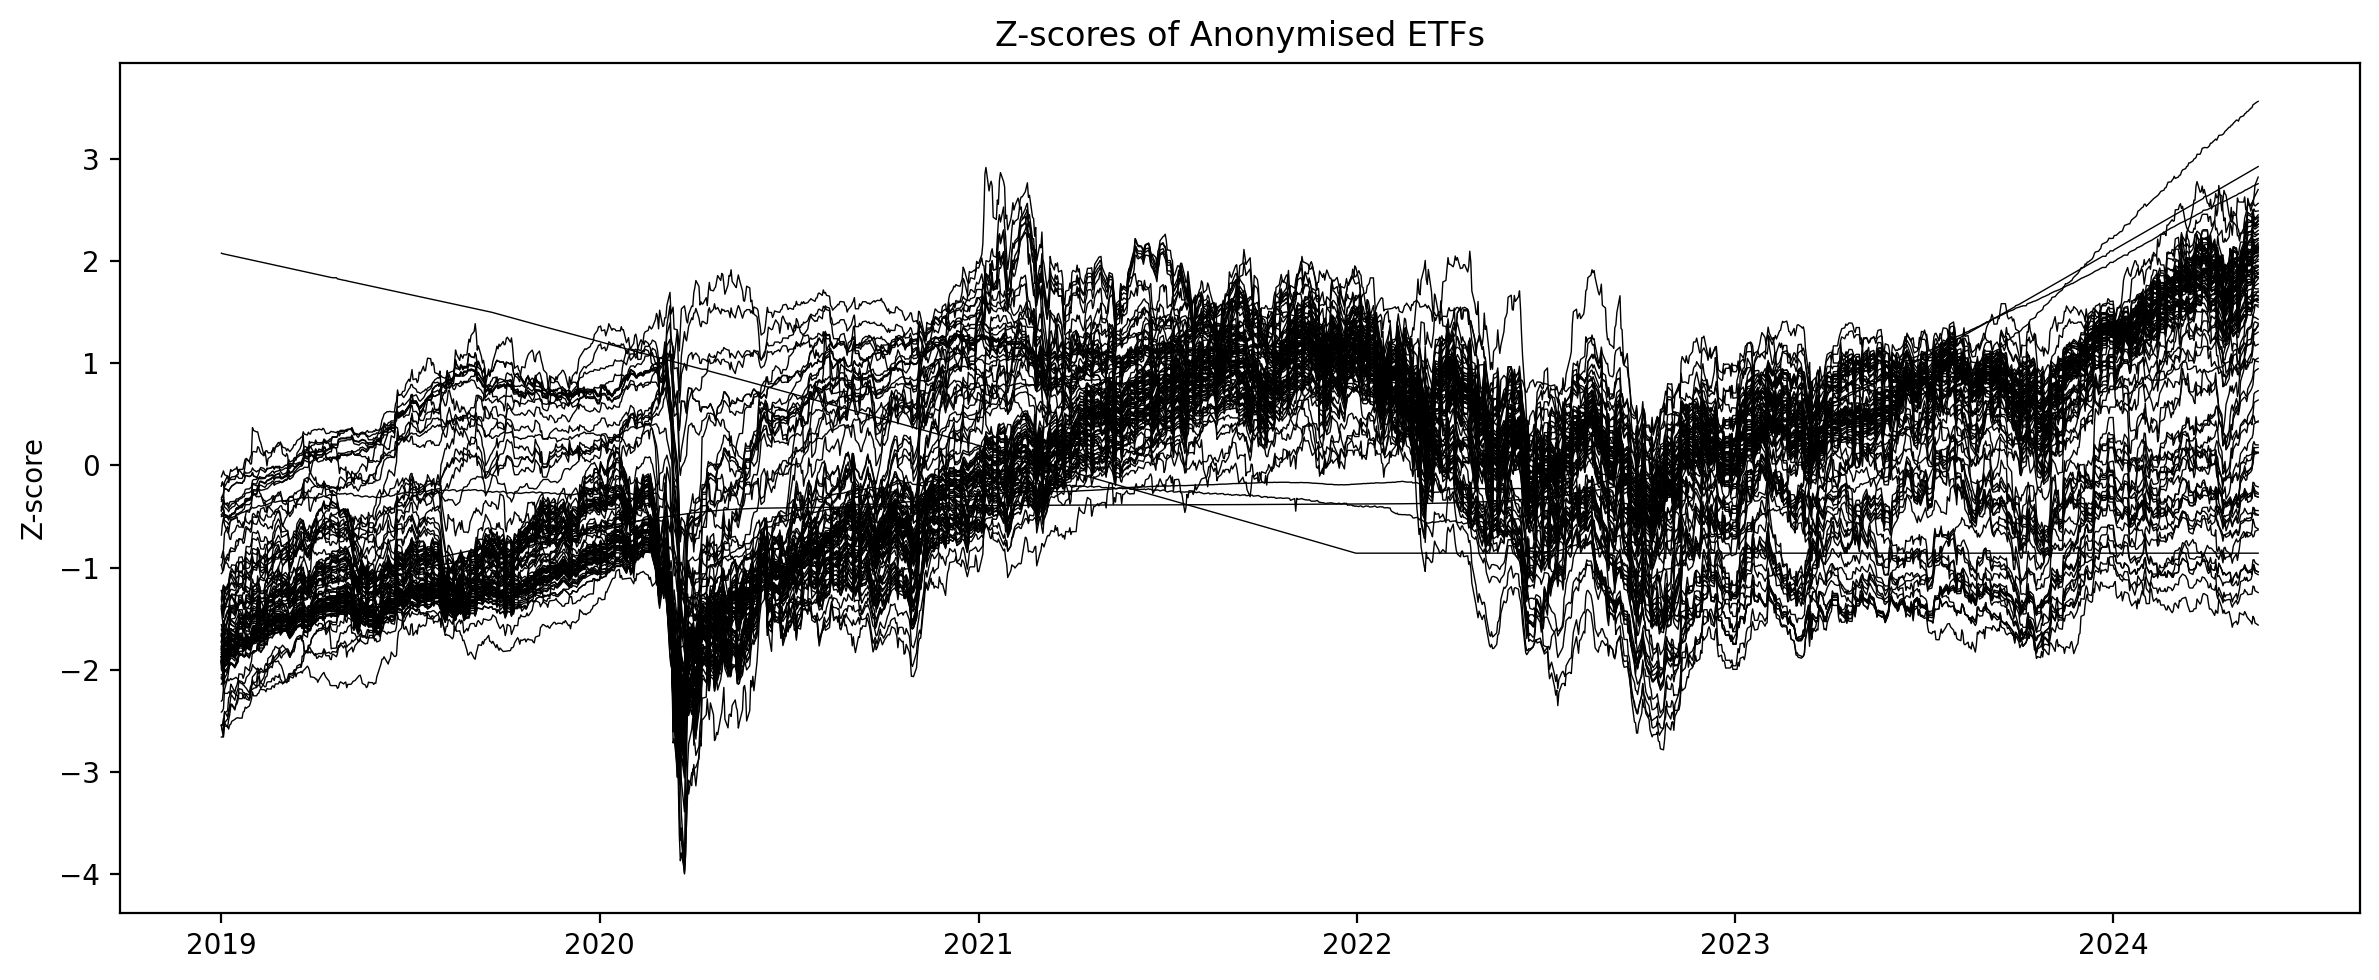

In [16]:
# Normalise ETF prices for comparison
df_zscores_etf = pd.DataFrame(scaler.fit_transform(df_etf_aligned),
                          columns=df_etf_aligned.columns,
                          index=df_etf_aligned.index)

# Plot
plt.figure(figsize=(12,5), dpi=200)
plt.plot(df_zscores_etf, linewidth=0.5, color='black')
plt.title("Z-scores of Anonymised ETFs",fontsize=12)
plt.ylabel("Z-score")
plt.tight_layout()
plt.show()

<Axes: >

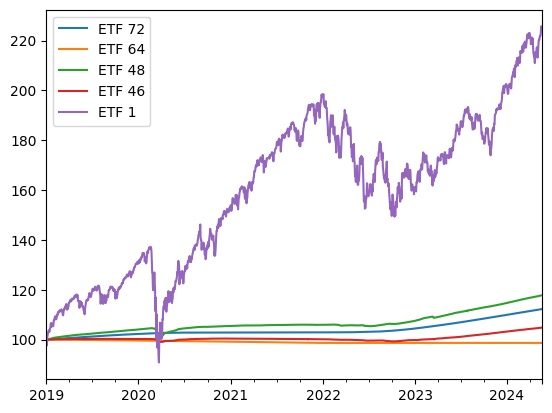

In [17]:
# Identified outlier ETFs
outliers = ['ETF 72','ETF 64', 'ETF 48', 'ETF 46']

# Drop outleirs in final ETF data frame
df_etf_aligned = df_etf.drop(columns=outliers)

# Outliers plot
df_etf[outliers + ['ETF 1 ']].plot() # ETF 1 for comparison


Key stats for main assets

In [18]:
df_main_lreturns = np.log(df_main_aligned / df_main_aligned.shift(1)).dropna()
df_stats = pd.DataFrame(index=df_main_lreturns.columns)

df_stats['Mean Daily Return'] = df_main_lreturns.mean()
df_stats['Annualized Return'] = df_main_lreturns.mean() * 252
df_stats['Daily Volatility'] = df_main_lreturns.std()
df_stats['Annualized Volatility'] = df_main_lreturns.std() * np.sqrt(252)
df_stats['Sharpe Ratio'] = df_stats['Annualized Return'] / df_stats['Annualized Volatility']
df_stats['Max Drawdown'] = (df_main_lreturns.cumsum() - df_main_lreturns.cumsum().cummax()).min()
df_stats['Skewness'] = df_main_lreturns.skew()
df_stats['Kurtosis'] = df_main_lreturns.kurtosis()

df_stats = df_stats.round(4)
df_stats

,Mean Daily Return,Annualized Return,Daily Volatility,Annualized Volatility,Sharpe Ratio,Max Drawdown,Skewness,Kurtosis
S&P 500,0.0006,0.1461,0.0129,0.2048,0.7131,-0.4130,-0.8512,15.5217
Nasdaq 100,0.0008,0.2026,0.0157,0.2486,0.8149,-0.4313,-0.5428,7.1506
US Small Caps,0.0004,0.0928,0.0167,0.2655,0.3494,-0.5399,-0.9722,10.6602
Euro Stoxx 50,0.0005,0.1184,0.0127,0.2009,0.5892,-0.4819,-1.0277,14.3658
UK FTSE,0.0003,0.0776,0.0107,0.1695,0.4579,-0.4187,-1.1891,16.7038
MSCI EM,0.0002,0.0471,0.0107,0.1692,0.2785,-0.4943,-0.5300,5.7239
Japan,0.0006,0.1393,0.0117,0.1858,0.7499,-0.3742,0.0268,3.6826
US IG,0.0001,0.0228,0.0055,0.0867,0.2628,-0.2879,-0.8262,9.9095
US HY,0.0002,0.0448,0.0046,0.0730,0.6135,-0.2452,-1.1361,22.7967
EU IG,0.0000,0.0006,0.0024,0.0384,0.0166,-0.1984,-0.5216,8.9893


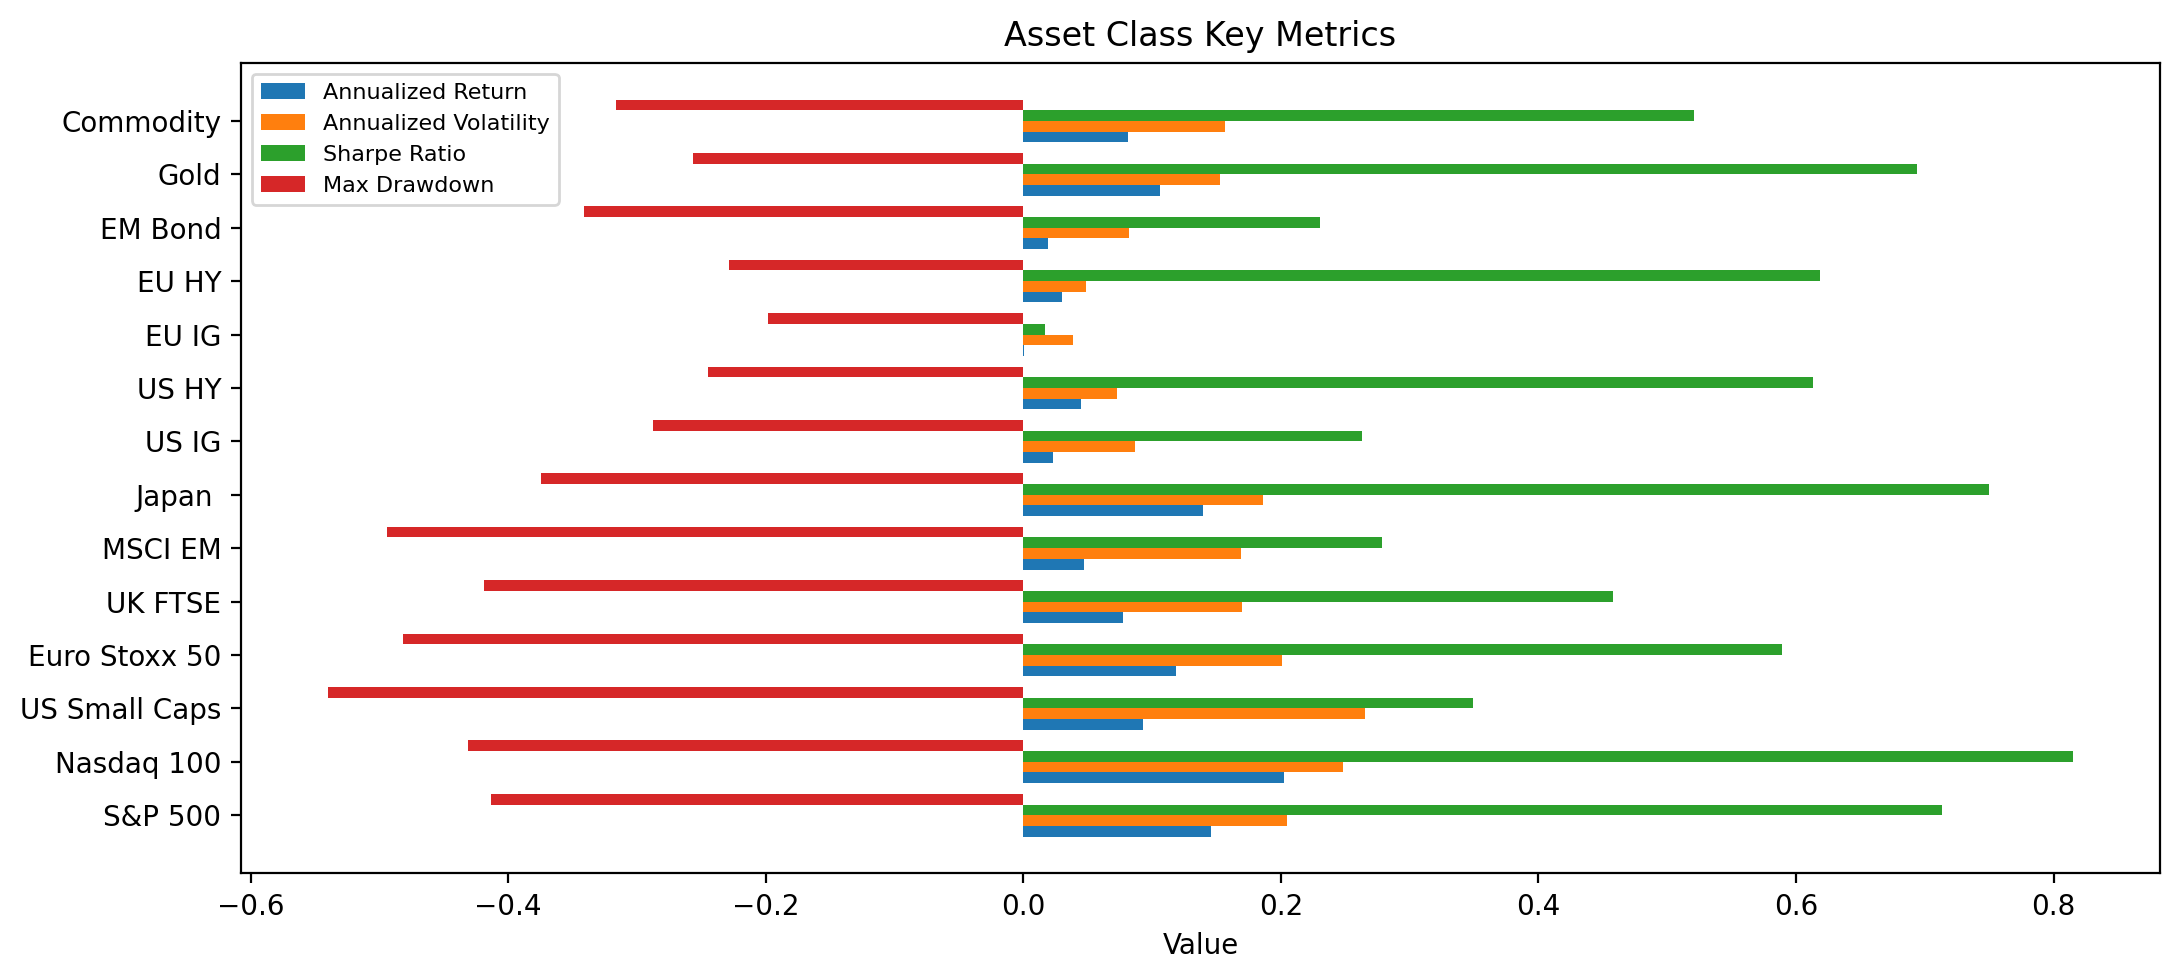

In [19]:
# Choose key metrics to plot
metrics = ['Annualized Return', 'Annualized Volatility', 'Sharpe Ratio', 'Max Drawdown']
df_plot = df_stats[metrics]

# Setup positions for horizontal bars
n_assets = len(df_plot)
bar_height = 0.2
y_pos = np.arange(n_assets)

plt.figure(figsize=(11,5), dpi=200)

# Plot each metric as a horizontal bar with offset
for i, metric in enumerate(metrics):
    plt.barh(y_pos + i*bar_height, df_plot[metric], height=bar_height, label=metric)

plt.yticks(y_pos + bar_height*(len(metrics)/2 - 0.5), df_plot.index)
plt.xlabel('Value')
plt.title('Asset Class Key Metrics', fontsize = 12)
plt.legend(fontsize=8, loc = 'upper left')
plt.tight_layout()
plt.show()


Variable calculation


In [20]:
# Daily log returns
df_lreturns = np.log(df_etf_aligned / df_etf_aligned.shift(1)).dropna()
df_main_lreturns = np.log(df_main_aligned / df_main_aligned.shift(1)).dropna()
df_myst_lreturns = np.log(df_myst_aligned / df_myst_aligned.shift(1)).dropna()

In [21]:
# Daily cummulative log returns
df_lreturns_cum = df_lreturns.cumsum()
df_main_lreturns_cum = df_main_lreturns.cumsum()

In [22]:
# Daily mean returns 
df_lreturns_mean = df_lreturns.mean()
df_main_lreturns_mean = df_main_lreturns.mean()

In [23]:
# Annualised returns
df_lreturns_annual = df_lreturns_mean*252
df_main_lreturns_annual = df_main_lreturns_mean*252


In [24]:
# Standard deviation of daily returns
df_vol = df_lreturns.std()
df_main_vol = df_main_lreturns.std()

In [25]:
# Standard deviation of annualised returns
df_vol_annual = df_vol * np.sqrt(252)
df_main_vol_annual = df_main_vol * np.sqrt(252)

In [26]:
# Sharpe ratio
df_sharpe_ratio = df_lreturns_annual / df_vol_annual
df_main_sharpe_ratio = df_main_lreturns_annual / df_main_vol_annual

In [27]:
# Sortino ratio

# Downside (negative) returns only
downside_returns = df_lreturns_annual[df_lreturns_annual < 0]

# Downside standard deviation
downside_std_annual = np.std(downside_returns) * np.sqrt(252)

# Caclulate Ratio
df_sortino_ratio = df_lreturns_annual / downside_std_annual

In [28]:
# Max Drawdown
max_drawdown = (df_lreturns_cum - df_lreturns_cum.cummax()).min().abs()

In [29]:
# Descriptive stats for key metrics

df_stats_etf = pd.DataFrame({
    'Returns (an.)' : df_lreturns_annual,
    'Volatility (an.)' : df_vol_annual,
    'Sharpe' : df_sharpe_ratio,
    'Sortino' : df_sortino_ratio,
    'Max Drawdown' : max_drawdown
})

df_stats_etf.describe().round(4)

,Returns (an.),Volatility (an.),Sharpe,Sortino,Max Drawdown
count,101.0000,101.0000,101.0000,101.0000,101.0000
mean,0.0888,0.1565,0.5017,1.0579,0.3879
std,0.0562,0.0623,0.2819,0.6702,0.1227
min,-0.0152,0.0105,-0.3299,-0.1814,0.0491
25%,0.0455,0.1443,0.3373,0.5418,0.3334
50%,0.1032,0.1712,0.5917,1.2302,0.4112
75%,0.1273,0.2021,0.7126,1.5176,0.4415
max,0.2379,0.2838,0.9264,2.8358,0.9163


Performance & risk metrics

Cummulative returns (log)

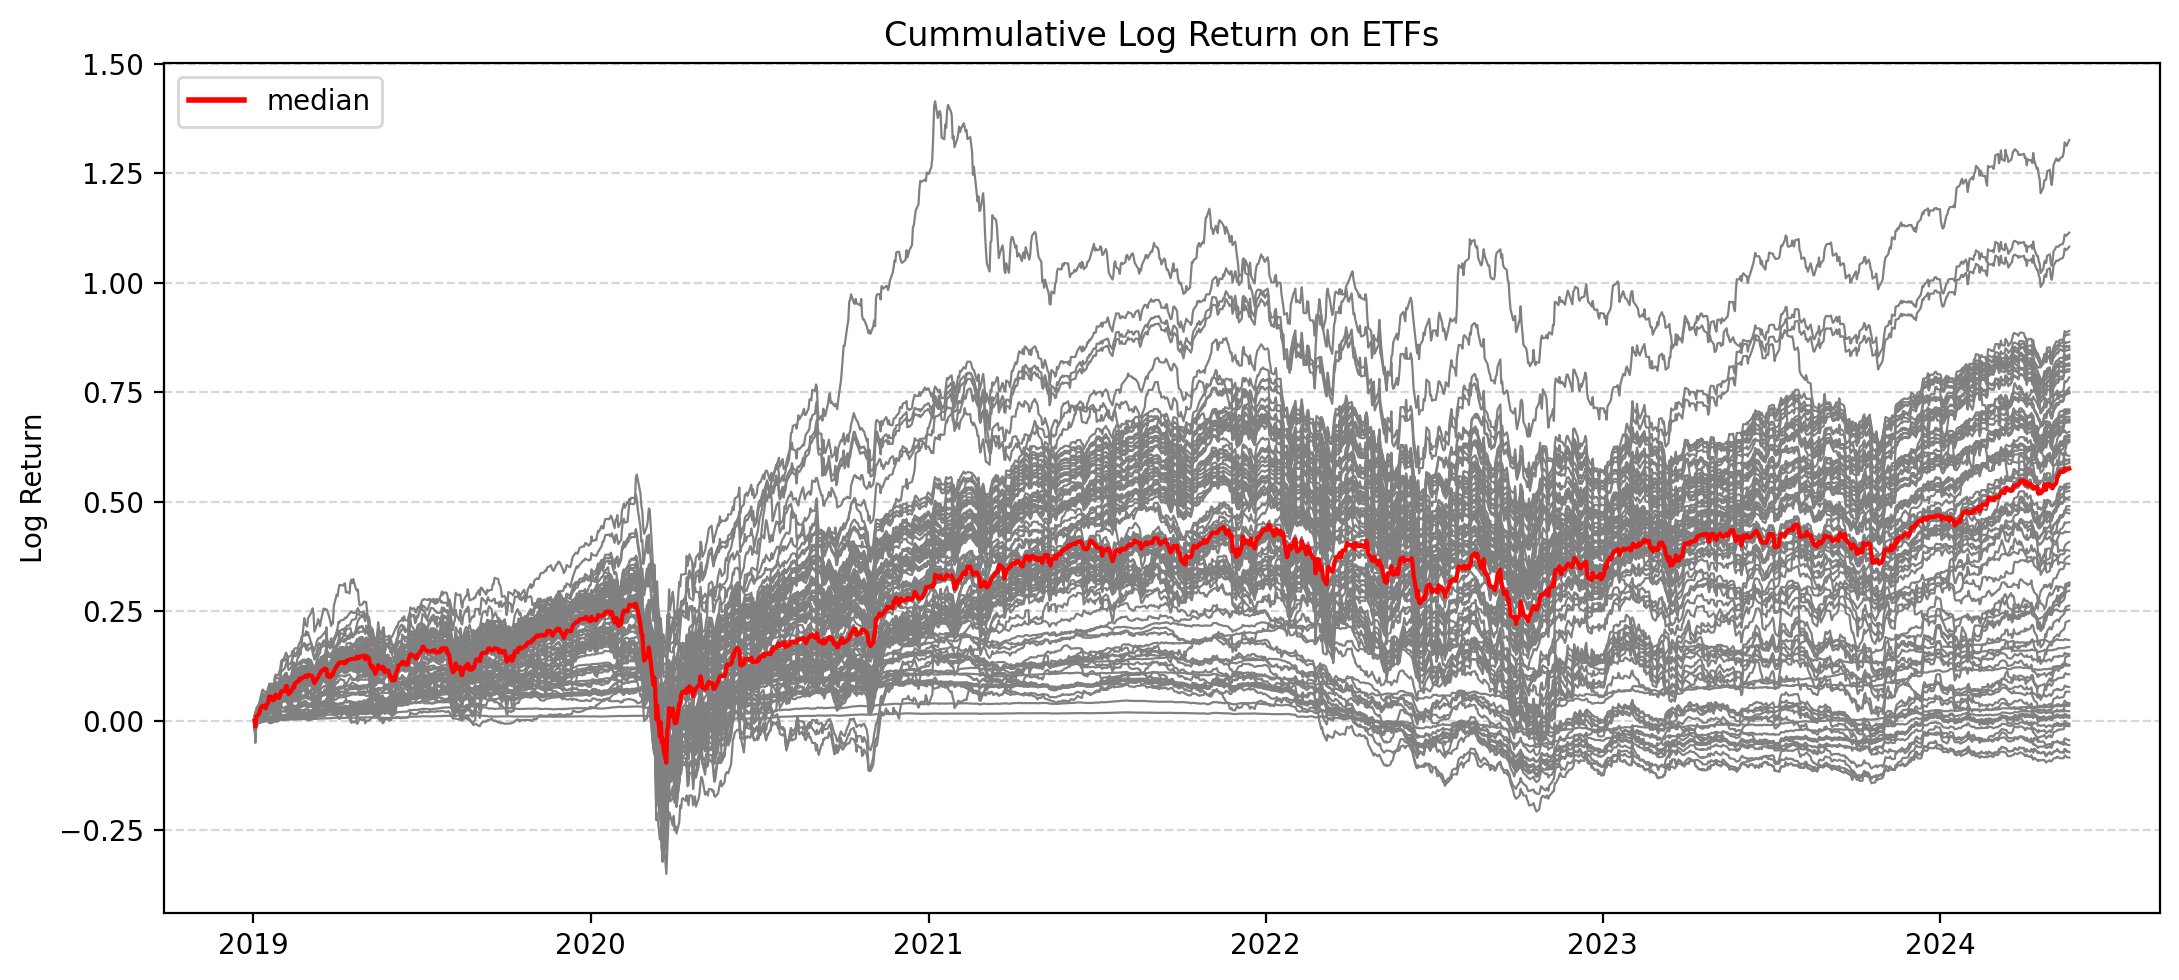

In [30]:
plt.figure(figsize=(11,5), dpi=200)

plt.plot(df_lreturns_cum, color='grey', linewidth=0.8)  # single color line
plt.plot(df_lreturns_cum.median(axis=1), color = 'red')

custom_legend = [Line2D([0], [0], color='red', lw=2, label='median')]
plt.legend(handles=custom_legend, loc='upper left', fontsize=10)

plt.title("Cummulative Log Return on ETFs", fontsize=12)
plt.ylabel("Log Return")

plt.grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()

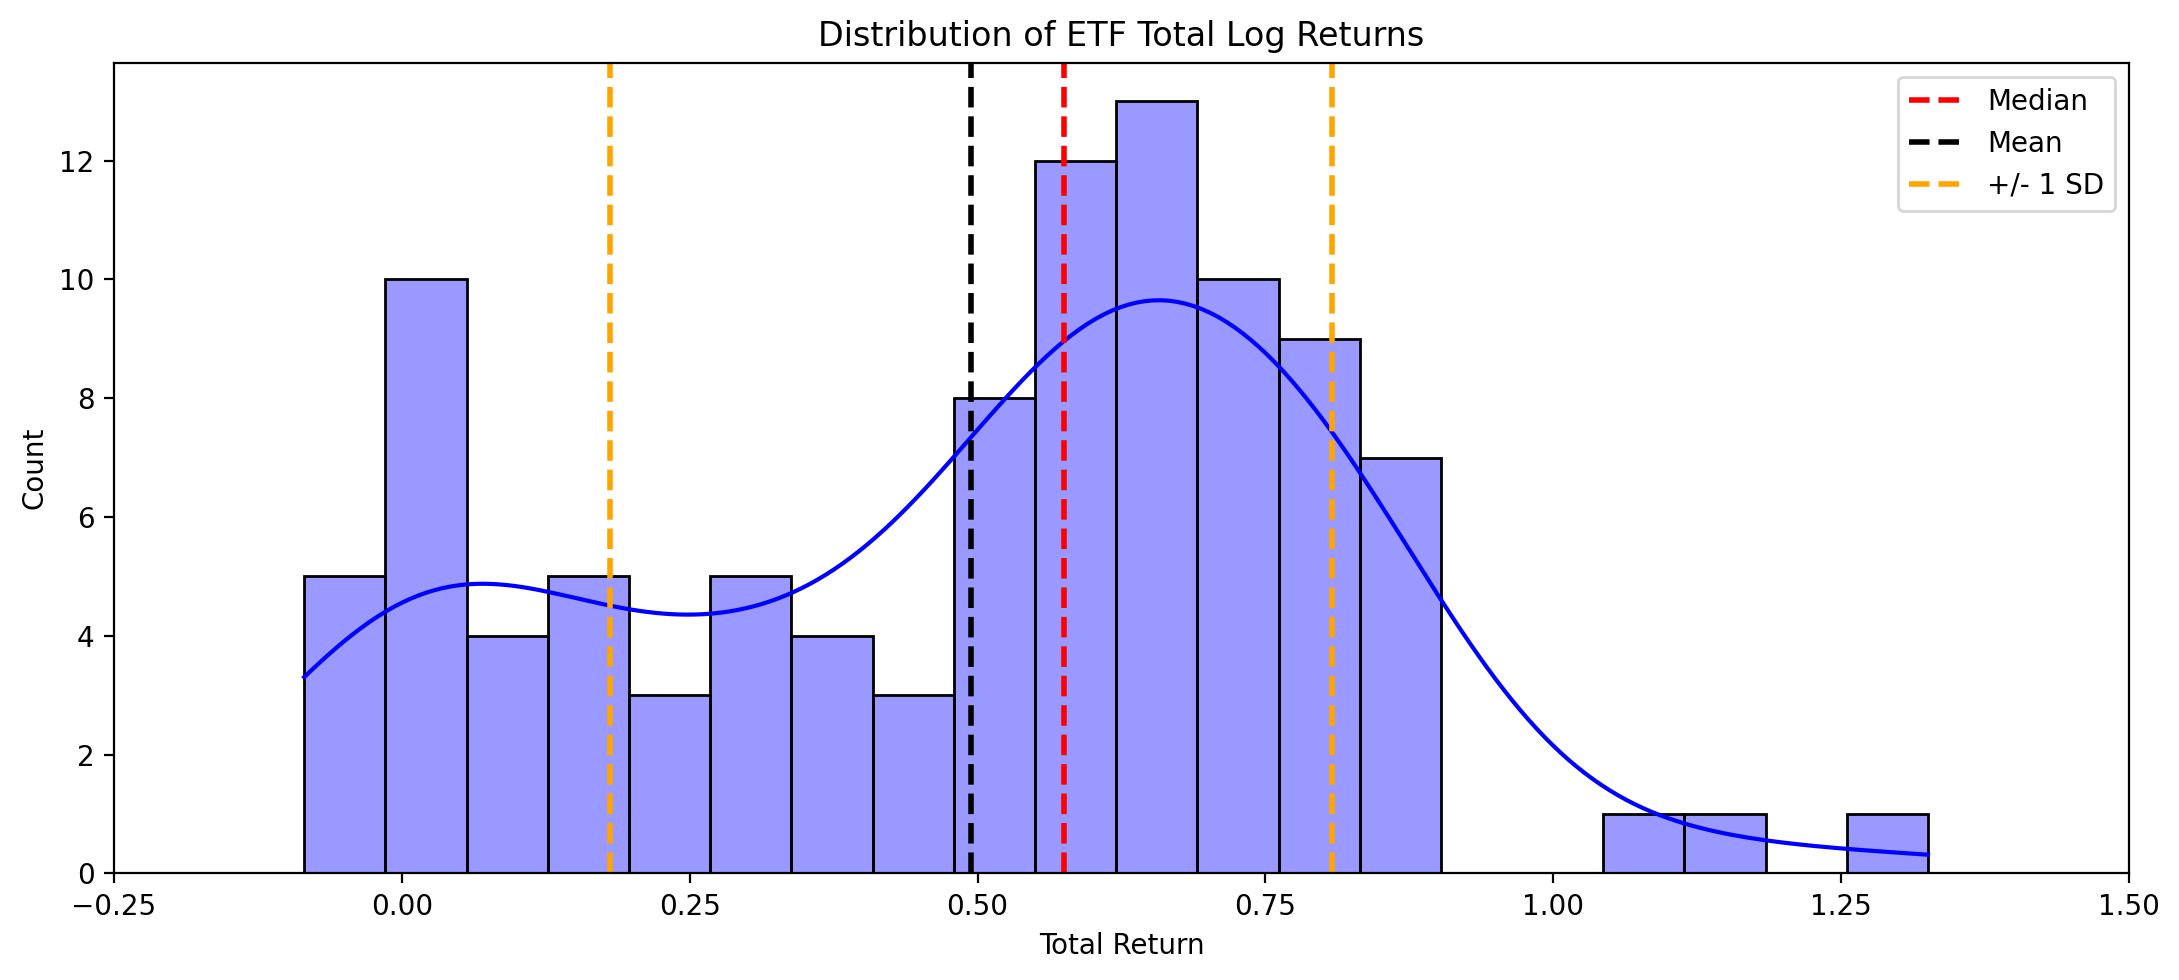

In [31]:
plt.figure(figsize=(11,5), dpi=200)

sns.histplot(
    df_lreturns_cum.iloc[-1],
    bins=20,
    stat='count',
    color='blue',
    alpha=0.4,
    kde=True
)

# Calculate statistics to display
mean = df_lreturns_cum.iloc[-1].mean()
median = df_lreturns_cum.iloc[-1].median()
std = df_lreturns_cum.iloc[-1].std()

plt.title('Distribution of ETF Total Log Returns', )
plt.xlabel('Total Return')

x_min, x_max = plt.xlim()
plt.xticks(np.arange(np.floor(x_min*4)/4, np.ceil(x_max*4)/4 + 0.25, 0.25))

# Add vertical lines
plt.axvline(median, color='red', linestyle='--', linewidth=2, label='Median')
plt.axvline(mean, color='black', linestyle='--', linewidth=2, label='Mean')
plt.axvline(mean + std, color='orange', linestyle='--', linewidth=2, label='+/- 1 SD')
plt.axvline(mean - std, color='orange', linestyle='--', linewidth=2)
plt.legend(fontsize=10)


plt.tight_layout()
plt.show()

Risk-adjusted returns (log)

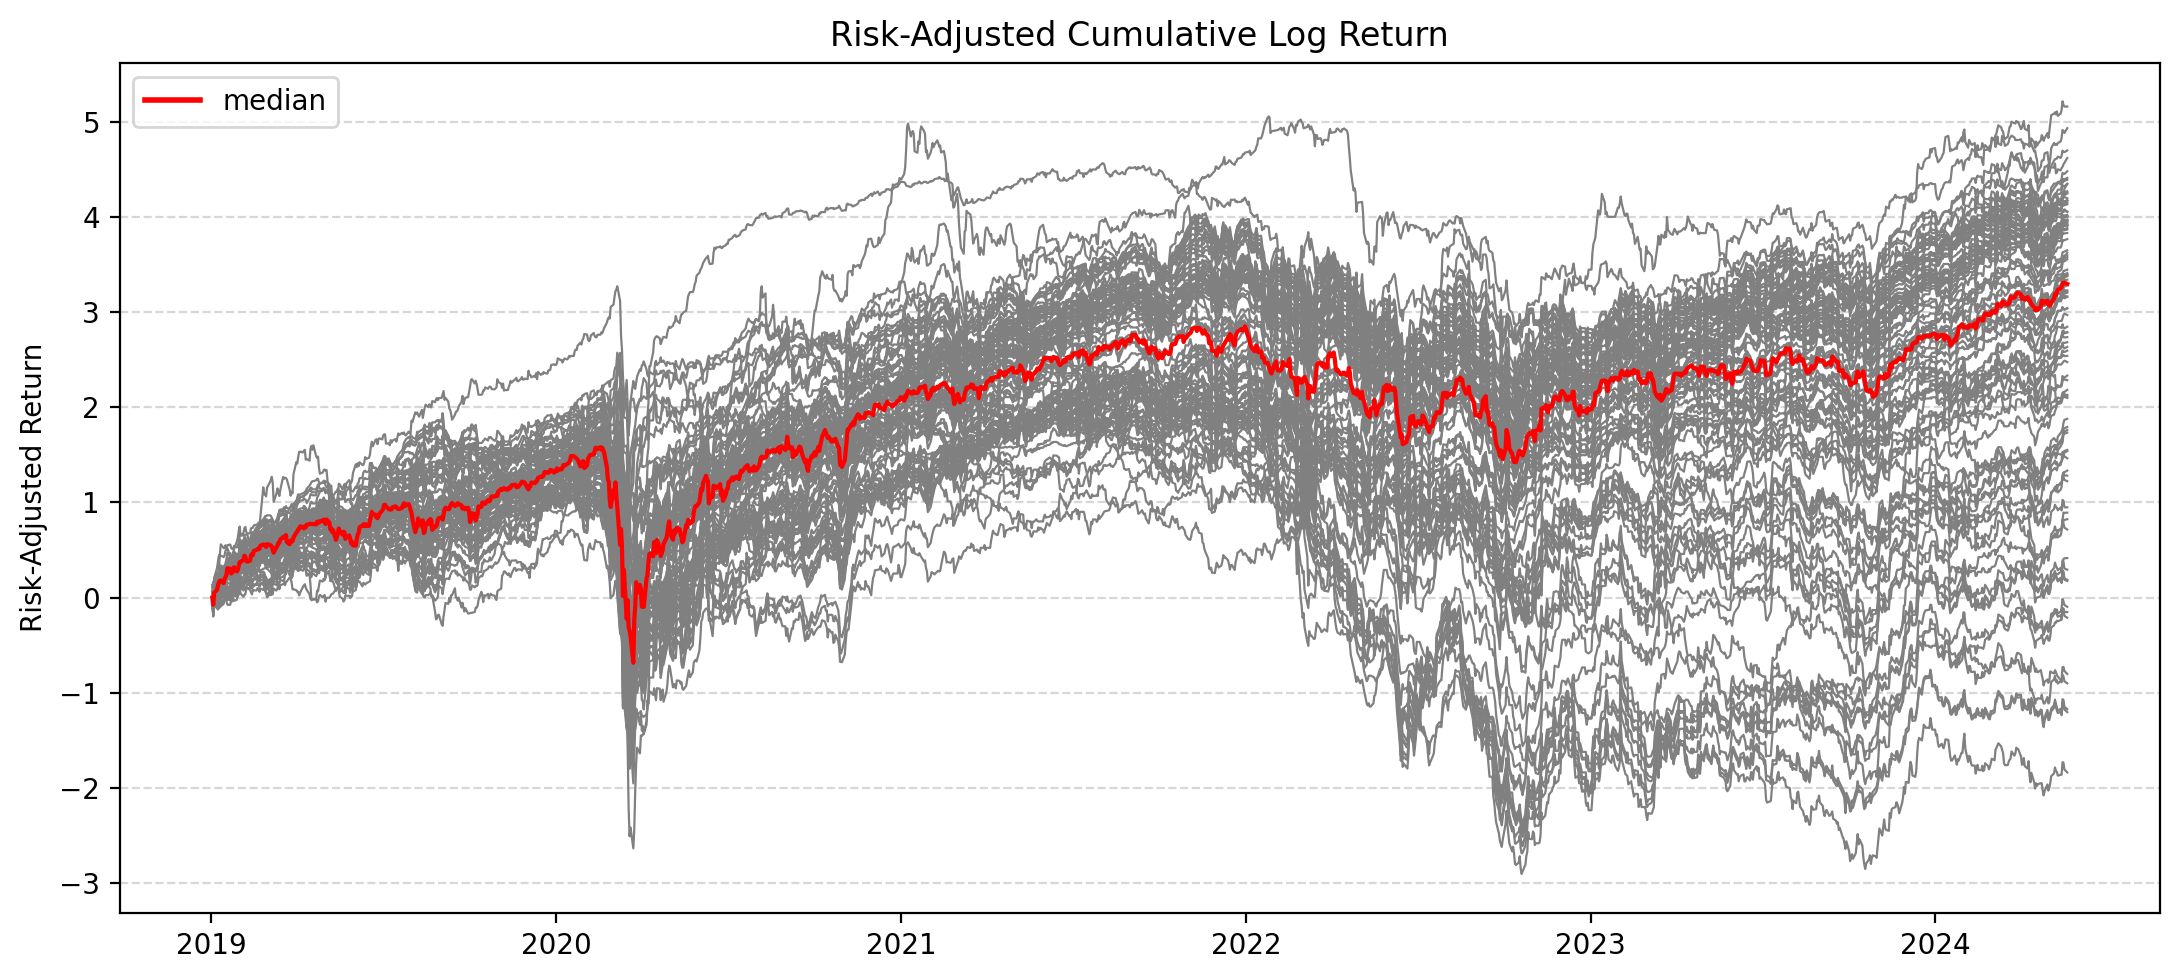

In [32]:
risk_adjusted_lreturns = (df_lreturns_cum / df_vol_annual)

plt.figure(figsize=(11,5), dpi=200)
plt.plot(risk_adjusted_lreturns, color='grey', linewidth=0.8)
plt.plot(risk_adjusted_lreturns.median(axis=1), color = 'red')

plt.title("Risk-Adjusted Cumulative Log Return", fontsize=12)
plt.ylabel("Risk-Adjusted Return")
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

custom_legend = [Line2D([0], [0], color='red', lw=2, label='median')]
plt.legend(handles=custom_legend, loc='upper left', fontsize=10)

plt.tight_layout()
plt.show()

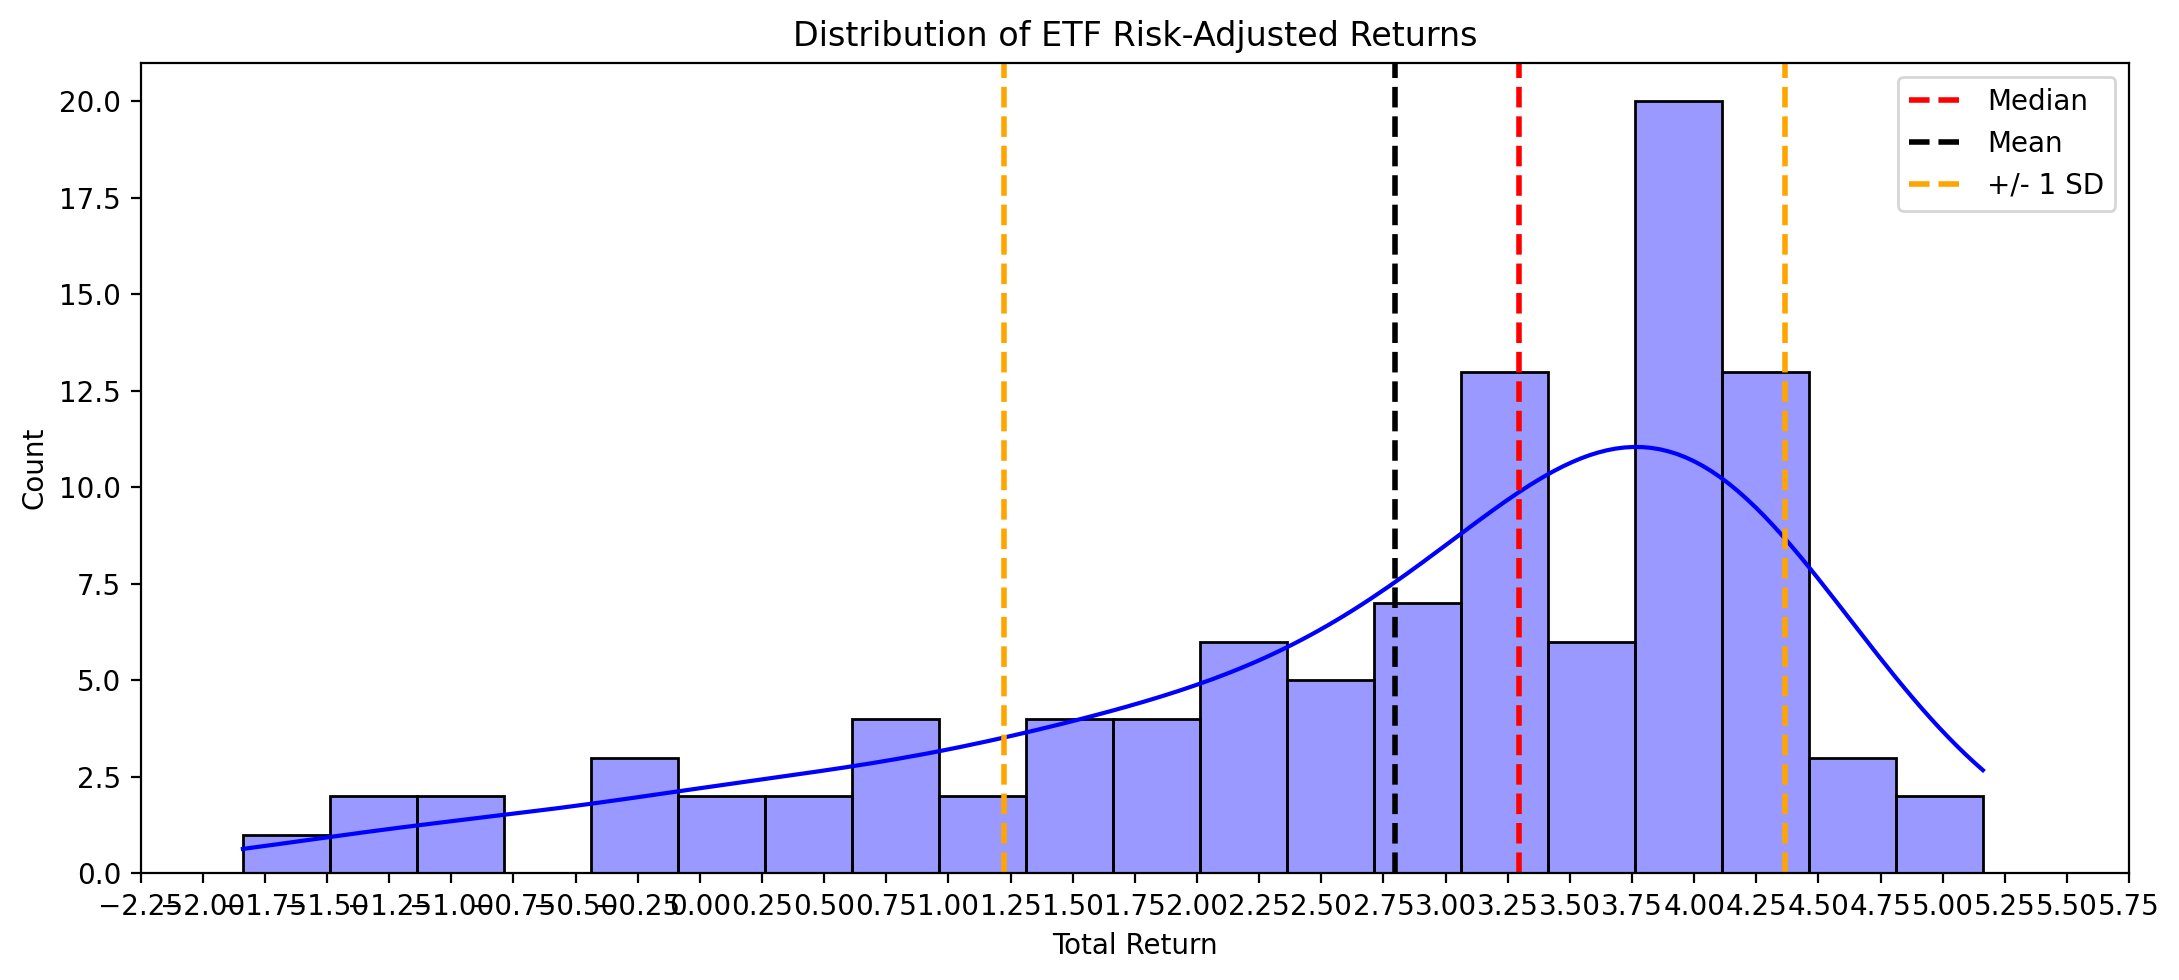

In [33]:
plt.figure(figsize=(11,5), dpi=200)

sns.histplot(
    risk_adjusted_lreturns.iloc[-1],
    bins=20,
    stat='count',
    color='blue',
    alpha=0.4,
    kde=True
)

# Calculate statistics to display
mean = risk_adjusted_lreturns.iloc[-1].mean()
median = risk_adjusted_lreturns.iloc[-1].median()
std = risk_adjusted_lreturns.iloc[-1].std()

plt.title('Distribution of ETF Risk-Adjusted Returns', )
plt.xlabel('Total Return')

x_min, x_max = plt.xlim()
plt.xticks(np.arange(np.floor(x_min*4)/4, np.ceil(x_max*4)/4 + 0.25, 0.25))

# Add vertical lines
plt.axvline(median, color='red', linestyle='--', linewidth=2, label='Median')
plt.axvline(mean, color='black', linestyle='--', linewidth=2, label='Mean')
plt.axvline(mean + std, color='orange', linestyle='--', linewidth=2, label='+/- 1 SD')
plt.axvline(mean - std, color='orange', linestyle='--', linewidth=2)
plt.legend(fontsize=10)


plt.tight_layout()
plt.show()

Annualised metrics

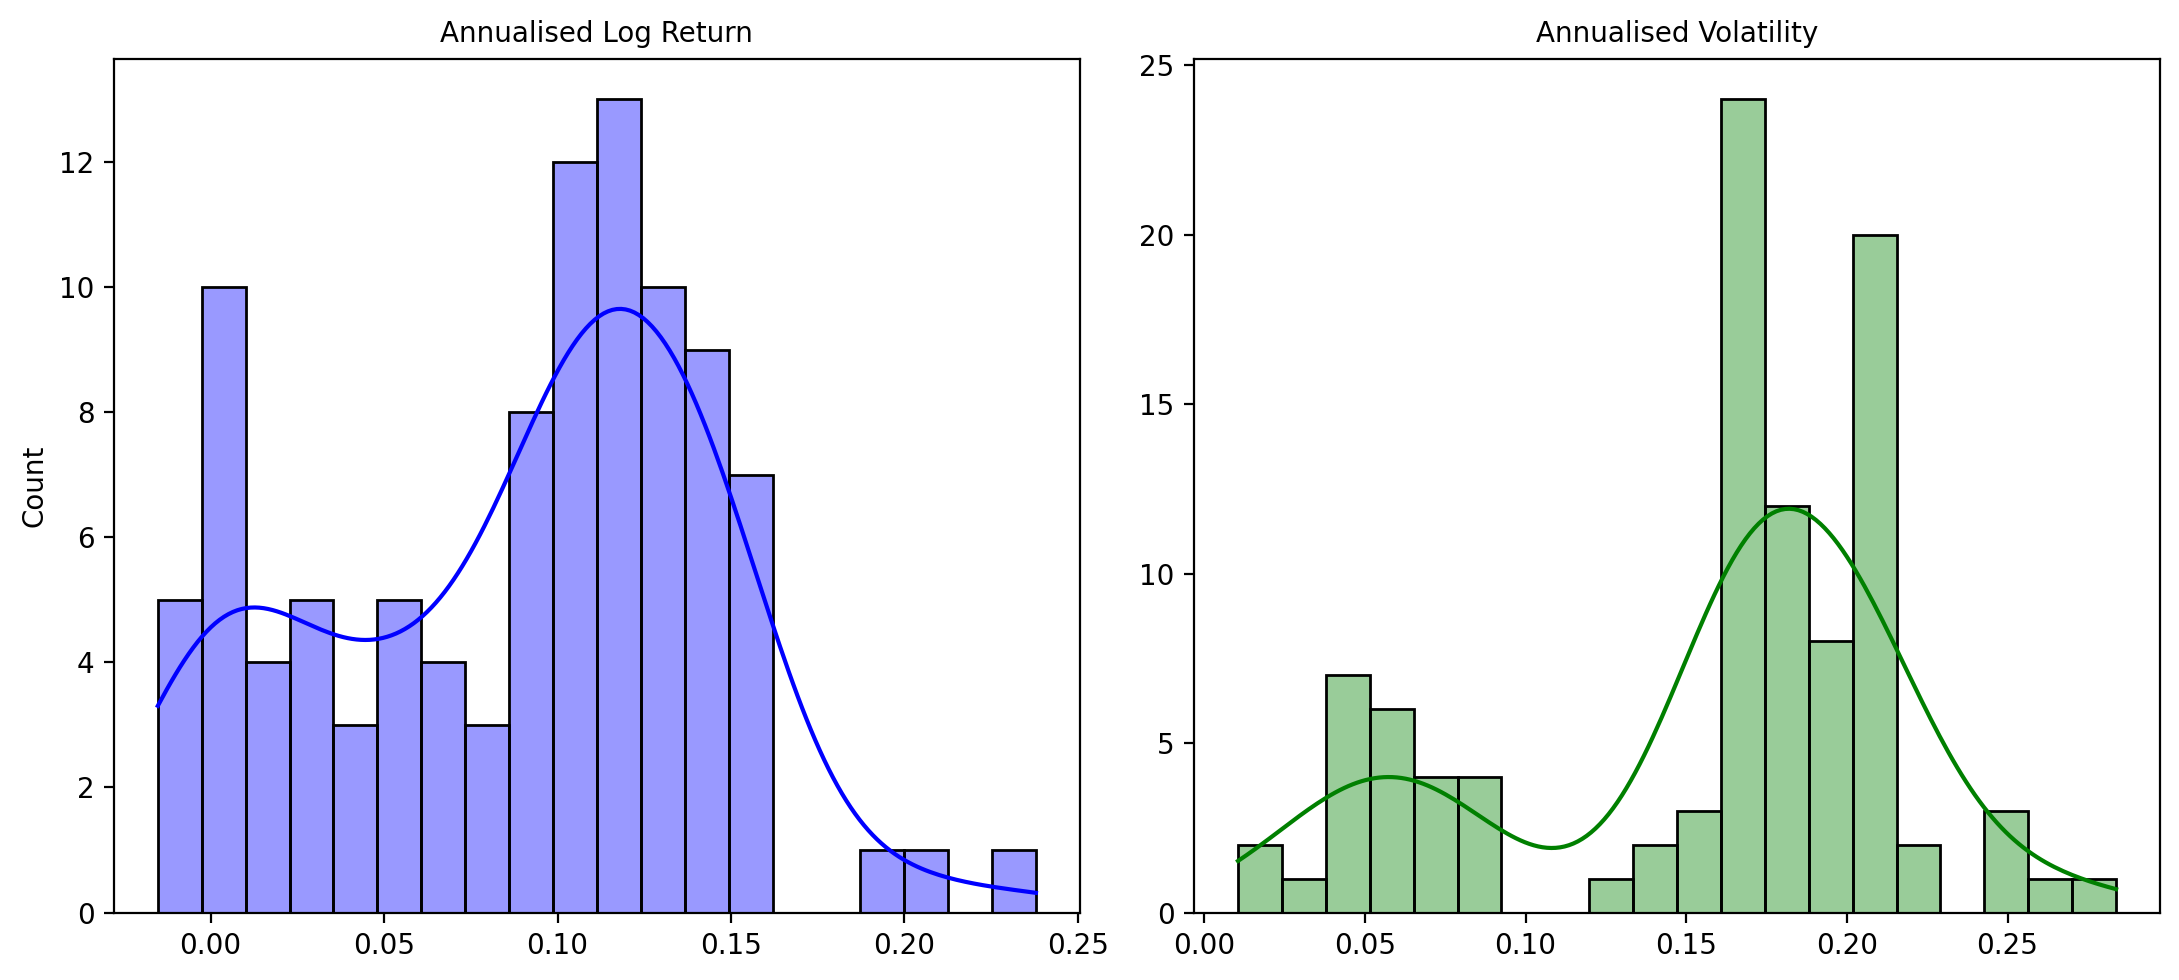

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(11,5), dpi=200)

sns.histplot(
    df_lreturns_annual,
    bins=20,
    stat='count',
    color='blue',
    alpha=0.4,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Annualised Log Return', fontsize = 10)
axes[0].set_ylabel('Count')

sns.histplot(
    df_vol_annual,
    bins=20,
    stat='count',
    color='green',
    alpha=0.4,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Annualised Volatility', fontsize = 10)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

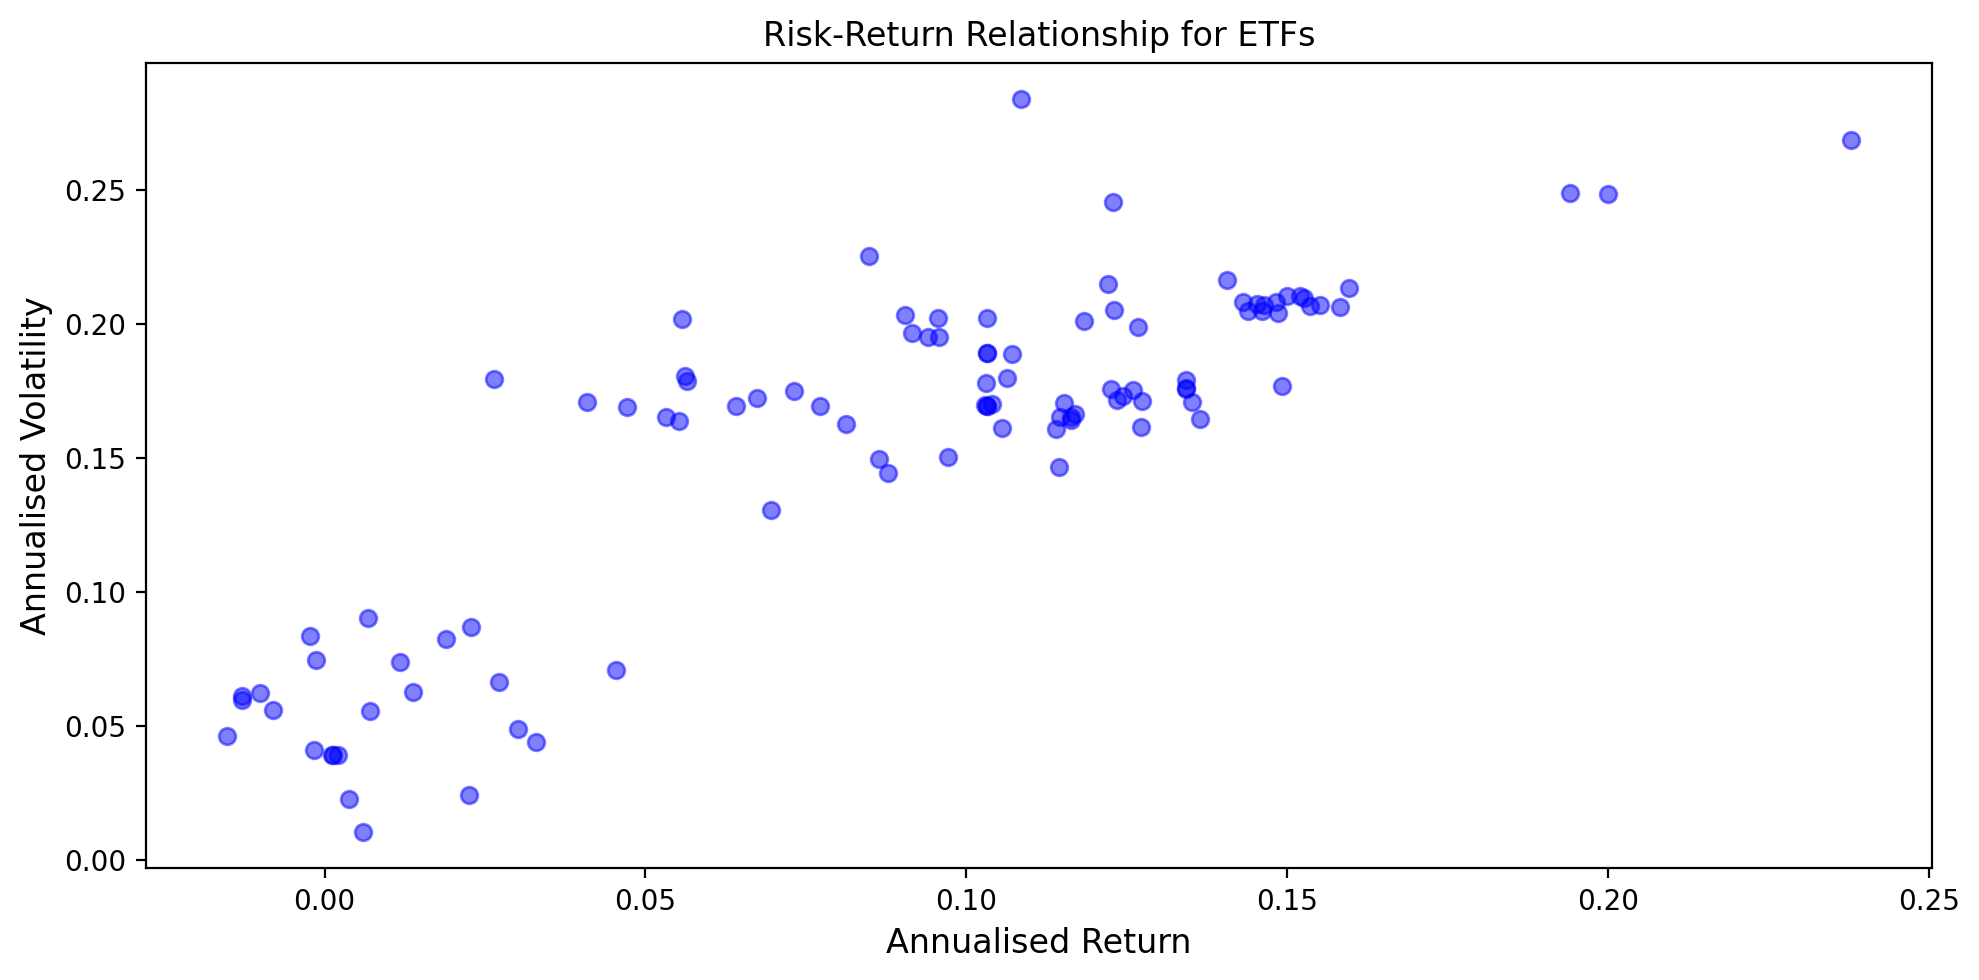

In [35]:
plt.figure(figsize=(10,5),dpi=200)
plt.scatter(x = df_lreturns_annual, y = df_vol_annual, alpha=0.5, color='blue')

plt.xlabel('Annualised Return', fontsize = 12)
plt.ylabel('Annualised Volatility',fontsize = 12)
plt.title('Risk-Return Relationship for ETFs', fontsize = 12)

plt.tight_layout()
plt.show()

In [36]:
# Correlation in clusters

high_vol = df_vol_annual.loc[df_vol_annual>0.1].index

df = pd.DataFrame({
    'vol' : df_vol_annual.loc[high_vol],
    'ret': df_lreturns_annual.loc[high_vol]
})

df.loc[df['ret'] < 0.17].corr()

,vol,ret
vol,1.000000,0.374759
ret,0.374759,1.000000


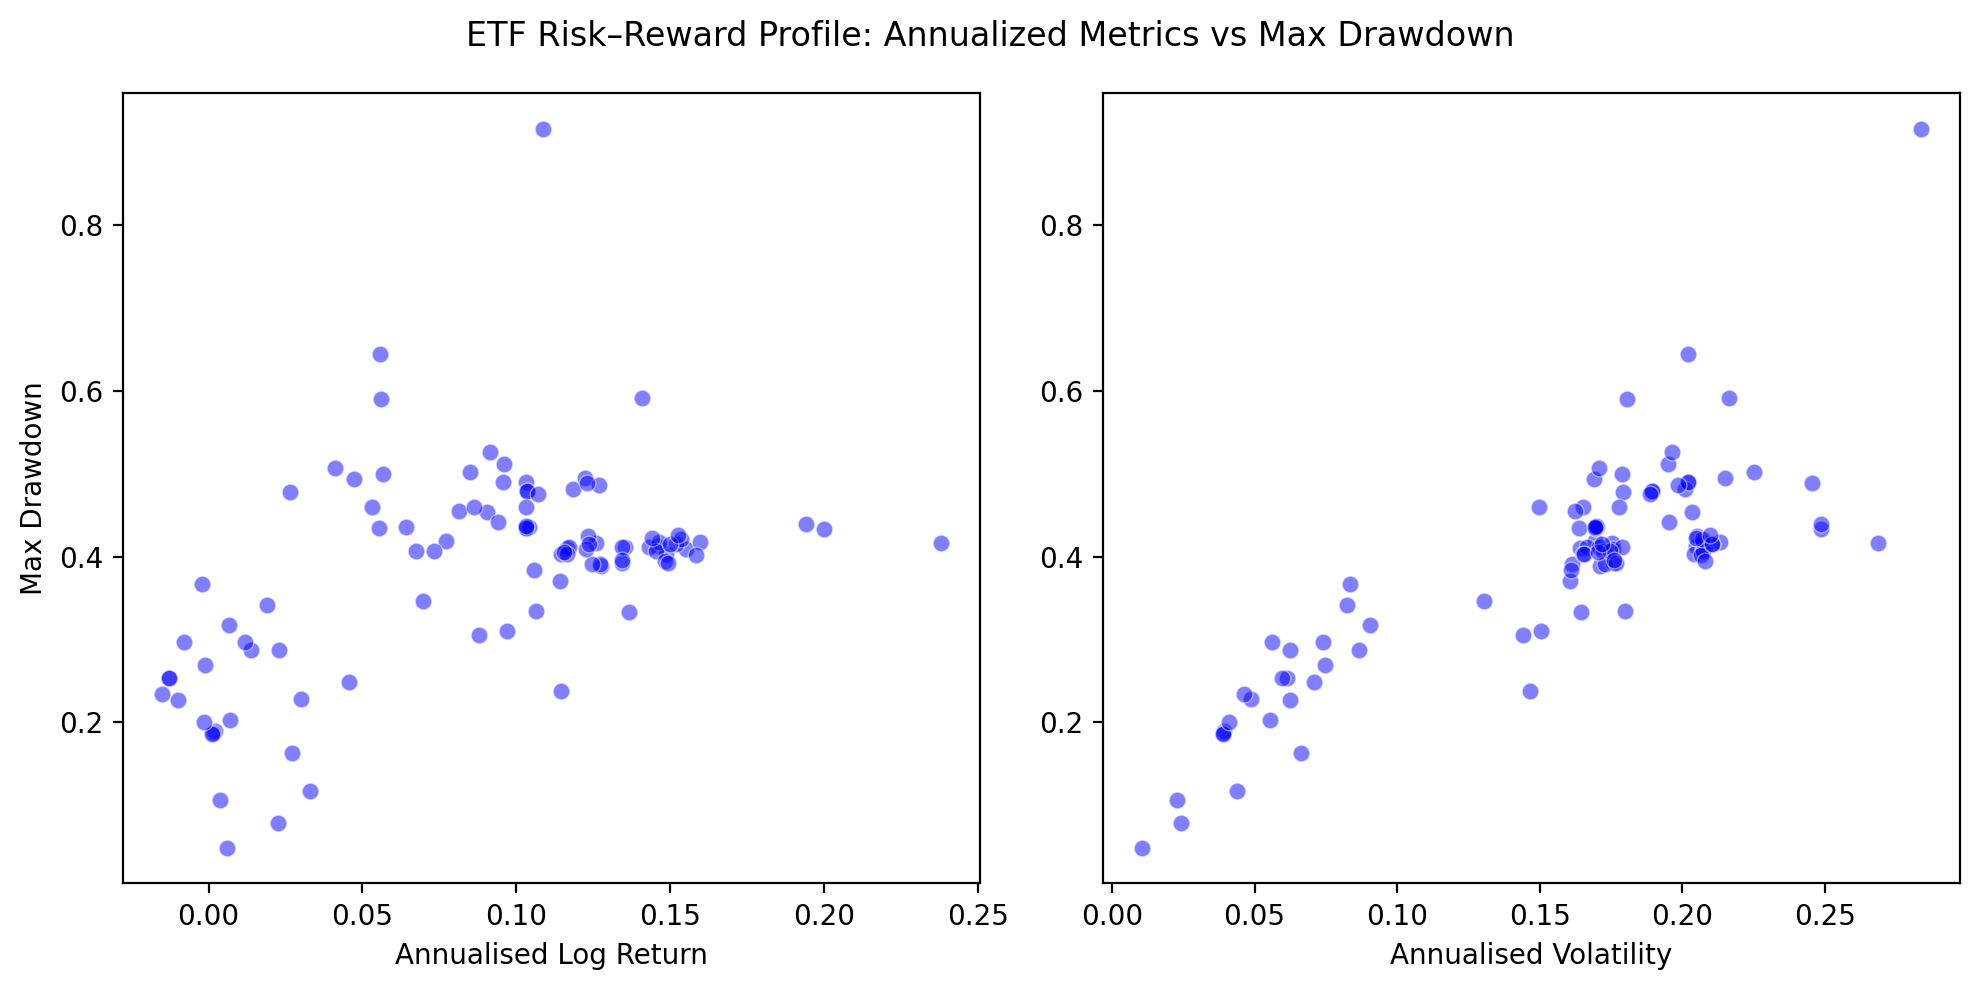

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(10,5), dpi=200)

sns.scatterplot(
    x = df_lreturns_annual,
    y = max_drawdown,
    ax=axes[0],
    c='blue',
    alpha = 0.5
)

axes[0].set_ylabel('Max Drawdown')
axes[0].set_xlabel('Annualised Log Return')

sns.scatterplot(
    x = df_vol_annual,
    y = max_drawdown,
    ax=axes[1],
    c='blue',
    alpha = 0.5
)

axes[1].set_ylabel('')
axes[1].set_xlabel('Annualised Volatility')

fig.suptitle('ETF Risk–Reward Profile: Annualized Metrics vs Max Drawdown', fontsize=12)

plt.tight_layout()
plt.show()


Sharpe + Sortino

C:\Users\HP\AppData\Local\Temp\ipykernel_33228\901600481.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Metric', y='Value', data=df_melt, palette='Set2')


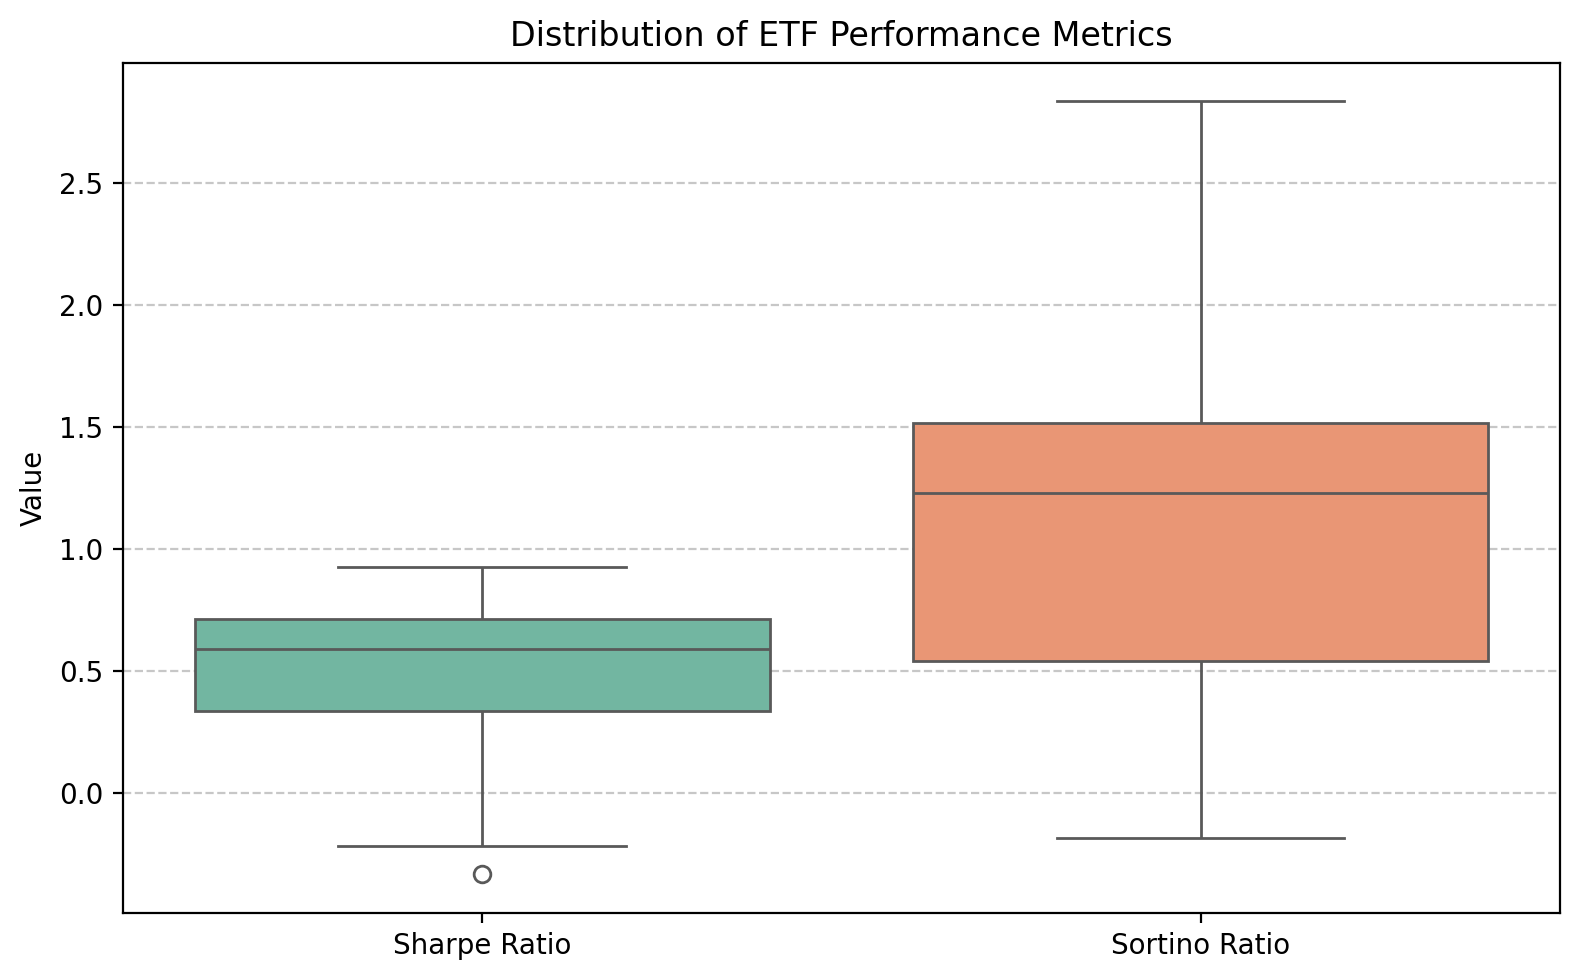

In [38]:
df_box = pd.DataFrame({
    'Sharpe Ratio': df_sharpe_ratio,
    'Sortino Ratio': df_sortino_ratio
})

# Melt the DataFrame to long format for Seaborn
df_melt = df_box.melt(var_name='Metric', value_name='Value')

plt.figure(figsize=(8,5), dpi=200)

sns.boxplot(x='Metric', y='Value', data=df_melt, palette='Set2')

plt.title('Distribution of ETF Performance Metrics')
plt.ylabel('Value')
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

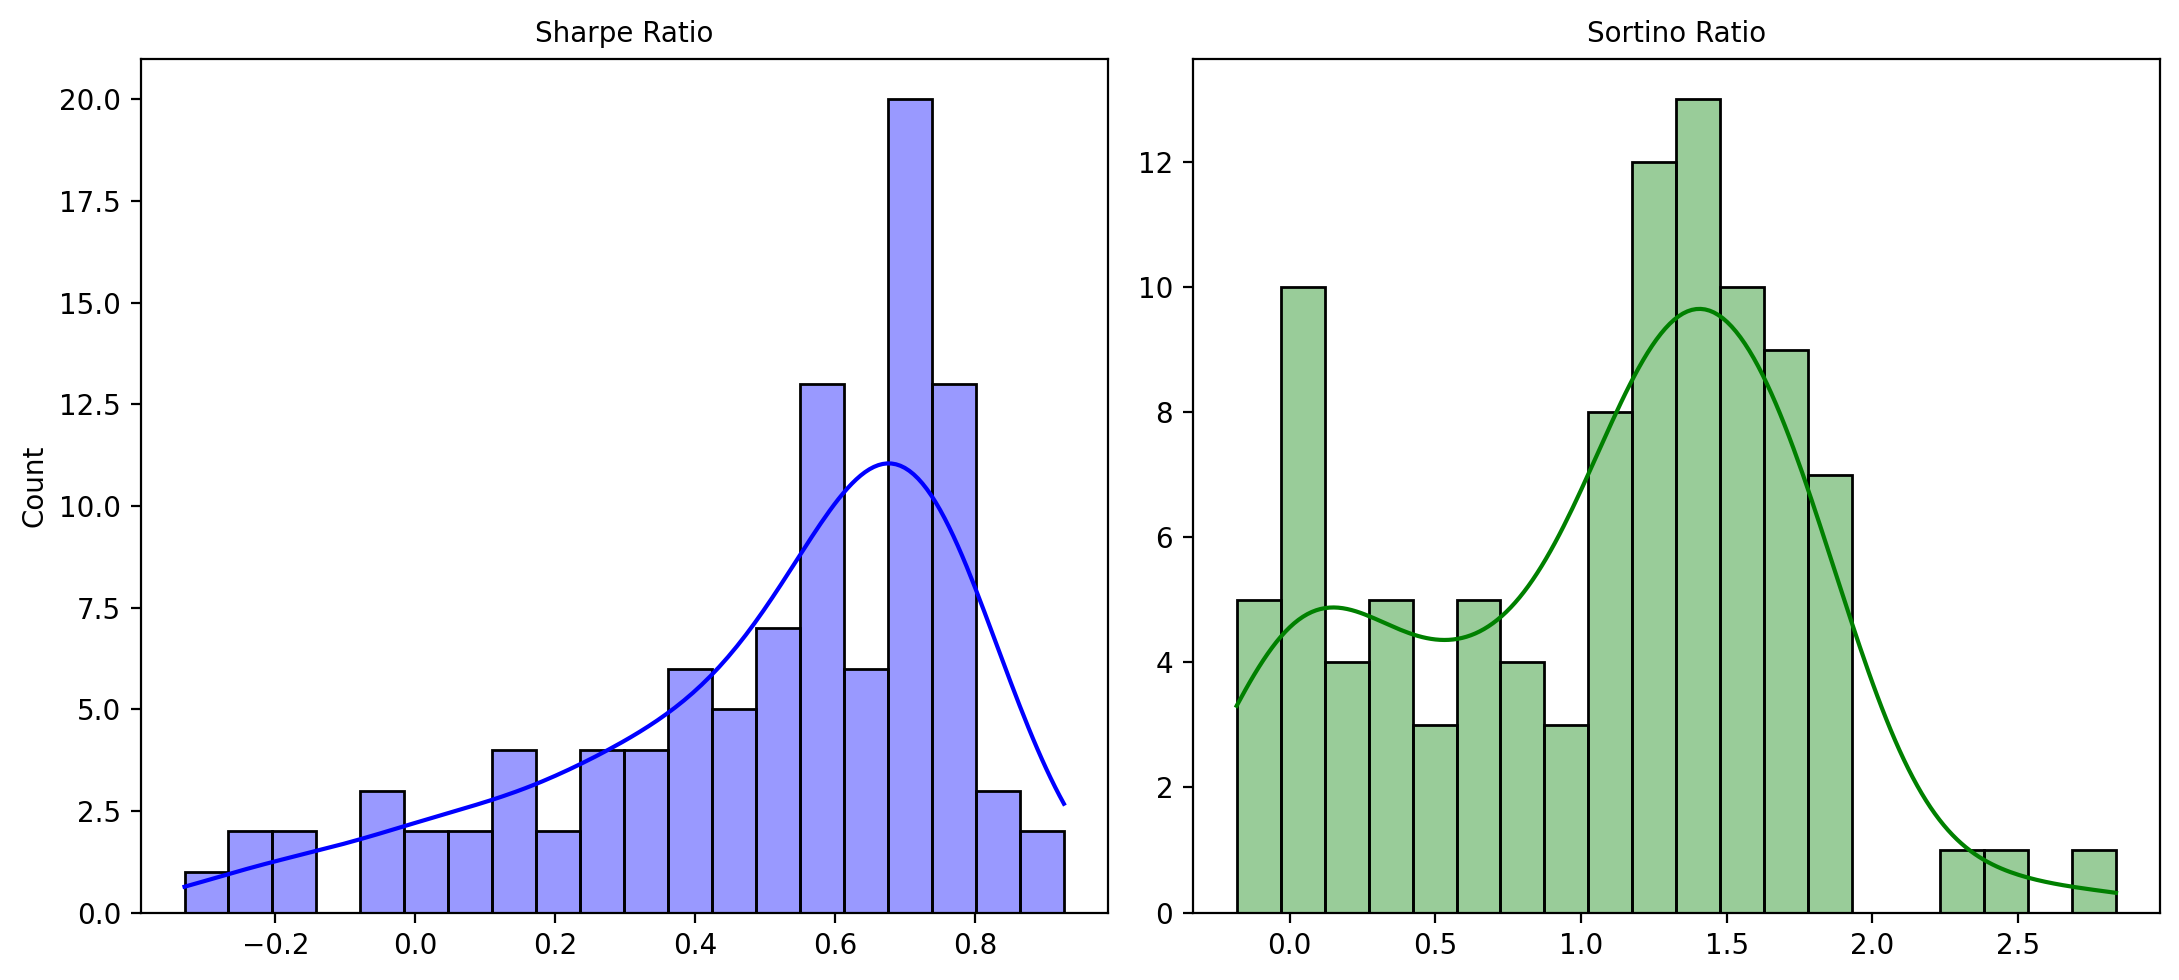

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(11,5), dpi=200)

# --- Sharpe ratio ---
sns.histplot(
    df_sharpe_ratio.loc[df_sharpe_ratio.between(-2, 2)],
    bins=20,
    stat='count',
    color='blue',
    alpha=0.4,
    kde=True,
    ax=axes[0]
)
axes[0].set_title('Sharpe Ratio', fontsize = 10)
axes[0].set_ylabel('Count')

# --- Sortino ratio ---
sns.histplot(
    df_sortino_ratio,
    bins=20,
    stat='count',
    color='green',
    alpha=0.4,
    kde=True,
    ax=axes[1]
)
axes[1].set_title('Sortino Ratio', fontsize = 10)
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


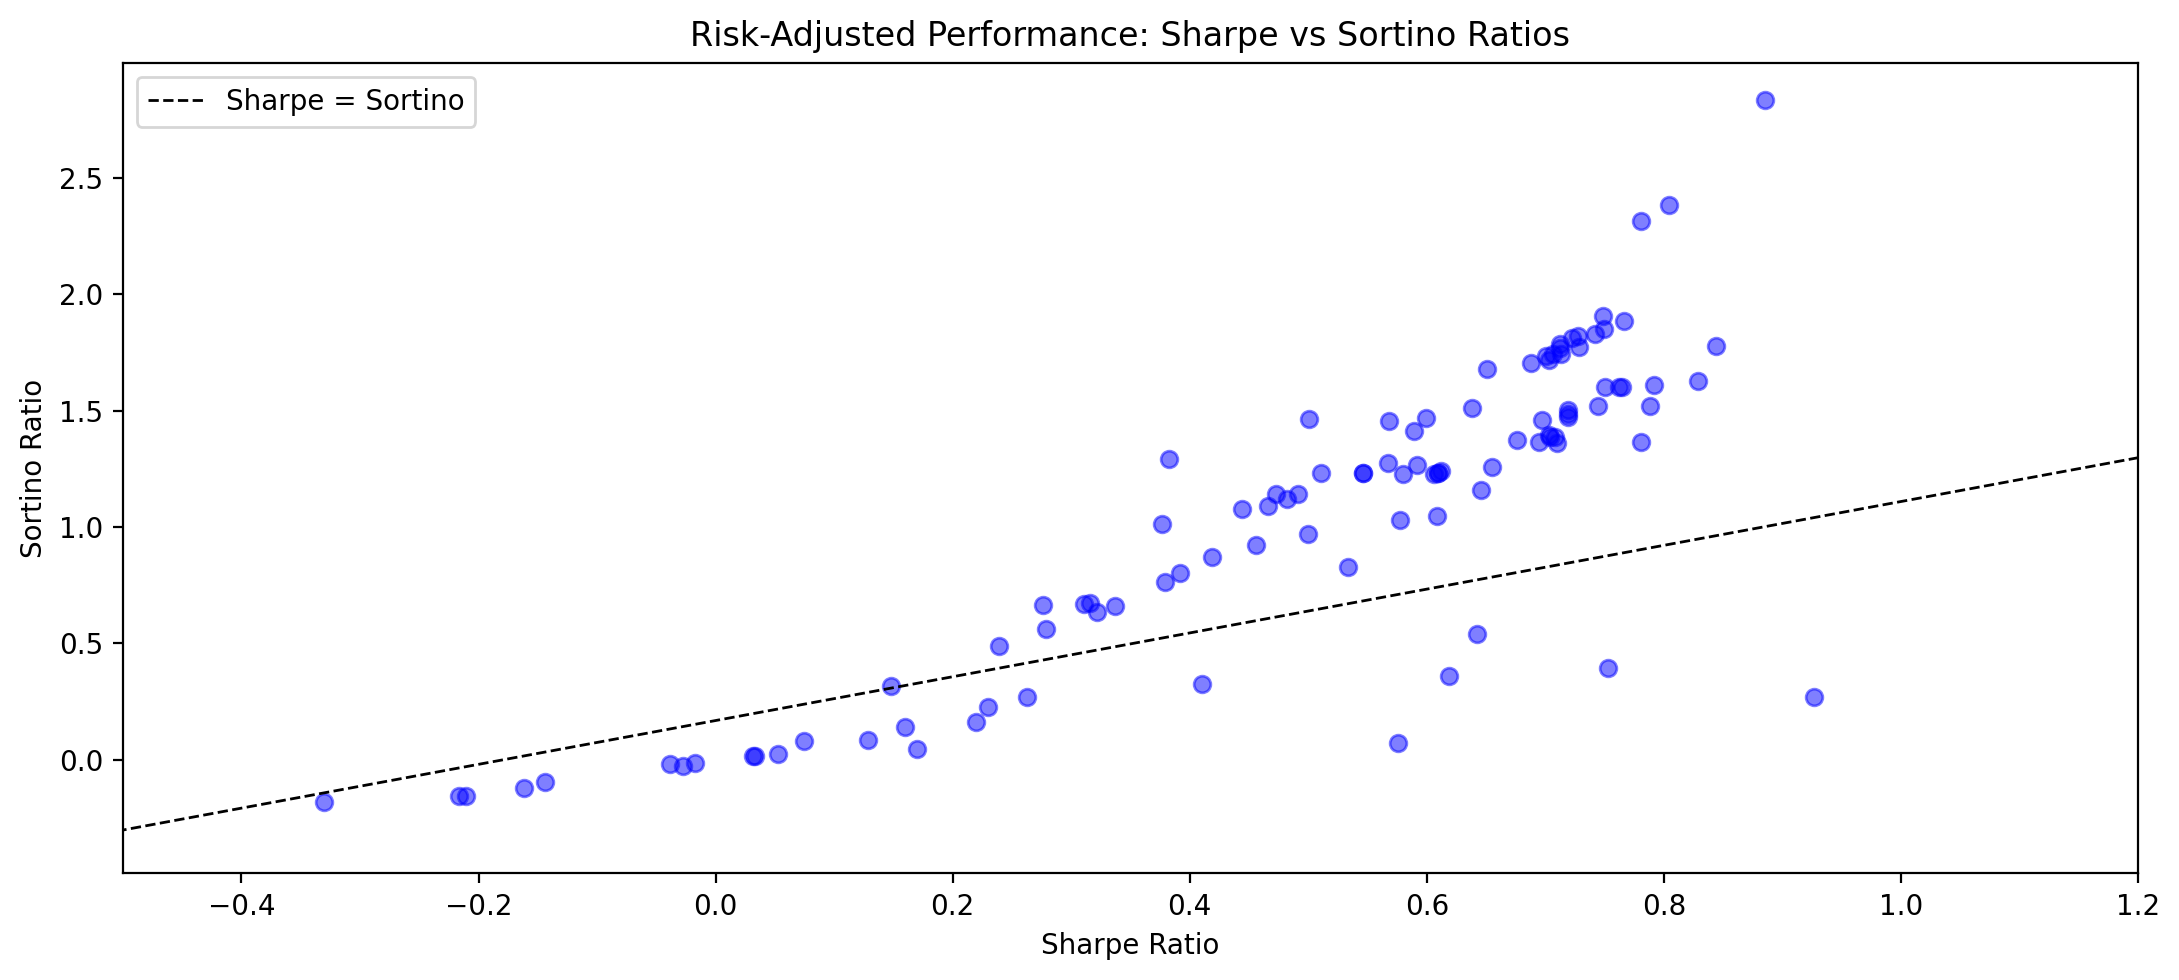

In [40]:
sharpe_trimmed = df_sharpe_ratio.loc[df_sharpe_ratio.between(-2,2)]
sortino_trimmed = df_sortino_ratio[sharpe_trimmed.index]

plt.figure(figsize=(11,5),dpi=200)
plt.scatter(x = sharpe_trimmed, y = sortino_trimmed, alpha=0.5, color='blue')

min_val = min(sharpe_trimmed.min(), sortino_trimmed.min())
max_val = max(sharpe_trimmed.max(), sortino_trimmed.max())

# Plot 45-degree line
plt.plot(
    [min_val-0.2, max_val],
    [min_val, max_val],
    linestyle='--',
    color='black',
    linewidth=1,
    label='45° line (Sharpe = Sortino)'
)

custom_legend = [Line2D([0], [0], color='black', linestyle='--',lw=1, label='Sharpe = Sortino')]
plt.legend(handles=custom_legend, loc='upper left', fontsize=10)

plt.xlim(-0.5, 1.2)
plt.xlabel('Sharpe Ratio', fontsize = 10)
plt.ylabel('Sortino Ratio',fontsize = 10)
plt.title('Risk-Adjusted Performance: Sharpe vs Sortino Ratios', fontsize = 12)

plt.tight_layout()
plt.show()

Summary (top / bottom 5)

In [41]:
df_lreturns_cum.iloc[-1].sort_values(ascending=False)

ETF 53    1.325425
ETF 12    1.114215
ETF 74    1.081848
ETF 23    0.889945
ETF 58    0.881672
            ...   
ETF 20   -0.045059
ETF 90   -0.056216
ETF 39   -0.071839
ETF 70   -0.072019
ETF 91   -0.084770
Name: 2024-05-20 00:00:00, Length: 101, dtype: float64

In [42]:
df_vol_annual.sort_values(ascending=False)

ETF 13    0.283782
ETF 53    0.268599
ETF 74    0.248660
ETF 12    0.248633
ETF 75    0.245441
            ...   
ETF 57    0.039048
ETF 78    0.038983
ETF 15    0.024292
ETF 43    0.022606
ETF 65    0.010486
Length: 101, dtype: float64

In [43]:
df_sharpe_ratio.sort_values(ascending=False)

ETF 15    0.926444
ETF 53    0.885696
ETF 84    0.843709
ETF 97    0.829252
ETF 12    0.804346
            ...   
ETF 20   -0.144287
ETF 90   -0.161986
ETF 39   -0.210712
ETF 70   -0.216322
ETF 91   -0.329945
Length: 101, dtype: float64

In [44]:
df_sortino_ratio.sort_values(ascending=False)

ETF 53    2.835768
ETF 12    2.383881
ETF 74    2.314633
ETF 23    1.904051
ETF 58    1.886351
            ...   
ETF 20   -0.096404
ETF 90   -0.120274
ETF 39   -0.153700
ETF 70   -0.154085
ETF 91   -0.181366
Length: 101, dtype: float64

Relational Analysis 

In [45]:
df_combined = pd.concat([df_etf_aligned, df_main_aligned], axis=1)
corr_matrix = df_combined.corr().loc[df_etf_aligned.columns, df_main_aligned.columns]

Correlation

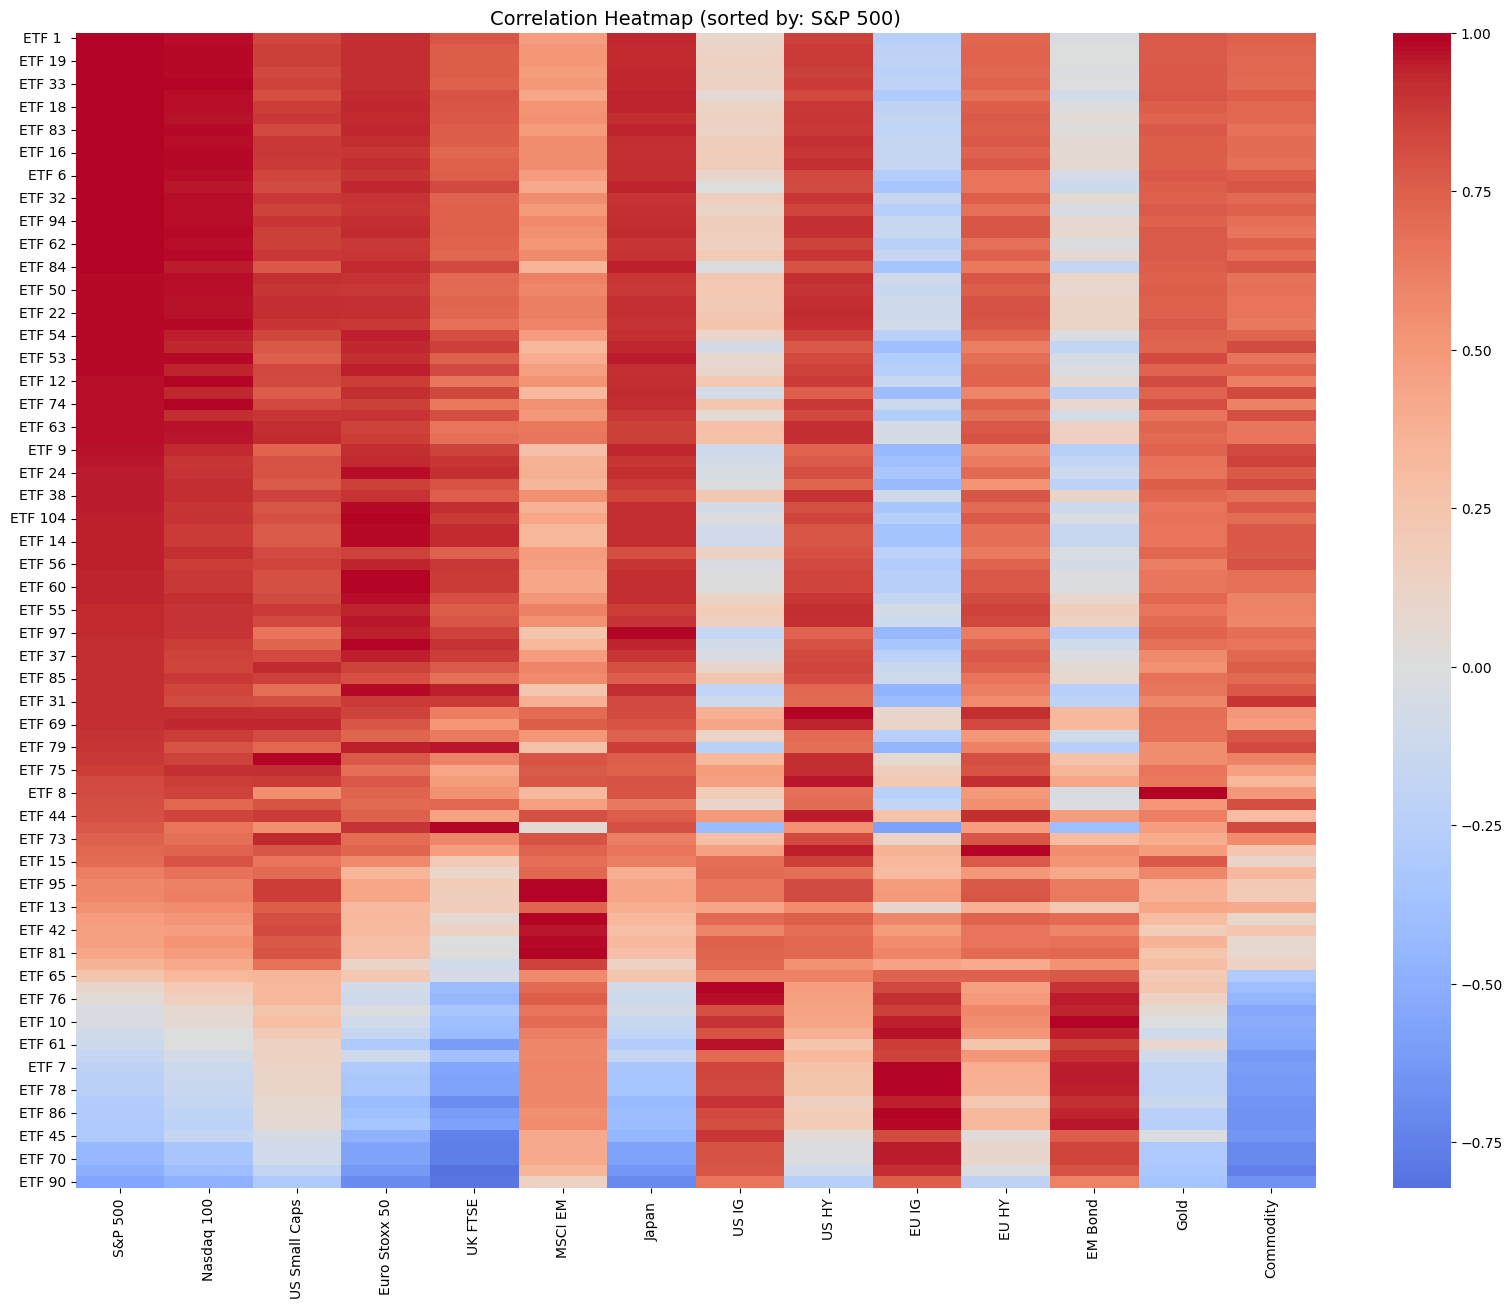

In [46]:
plt.figure(figsize=(20, 15))
sns.heatmap(corr_matrix.sort_values(by='S&P 500', ascending=False), 
            cmap="coolwarm",     # red/blue diverging colors
            center=0,            # 0 = white midpoint
            annot=False)         # set to True if you want numbers
plt.title("Correlation Heatmap (sorted by: S&P 500)", fontsize=14)
plt.show()

Linear Regression

In [49]:
# Data Frame for both ETFs and MAs
df_lreturns_all = pd.concat([df_lreturns, df_myst_lreturns], axis=1)

import statsmodels.api as sm

# Empty frames to store regression parameters
betas = pd.DataFrame(index=df_lreturns_all.columns, 
                     columns=df_main_aligned.columns)

pvals = pd.DataFrame(index=df_lreturns_all.columns, 
                     columns=df_main_aligned.columns)

contrib = pd.DataFrame(index=df_lreturns_all.columns, 
                       columns=df_main_aligned.columns)

# Empty dictionary to store models
models = {}

for etf in df_lreturns_all.columns:
    y = df_lreturns_all[etf]
    X = sm.add_constant(df_main_lreturns)
    model = sm.OLS(y, X).fit()

    
    # store betas, p-values (exclude constant term) and models 
    betas.loc[etf] = model.params.drop('const')
    pvals.loc[etf] = model.pvalues.drop('const')
    models[etf] = model
    contrib.loc[etf] = model.params.drop('const') * df_lreturns_all[etf].sum()

In [50]:
# Filter out isignificant betas
significance = (pvals <= 0.05).astype(float) # 1 = significant, 0 otherwise
betas_signif = (betas * significance).astype(float)

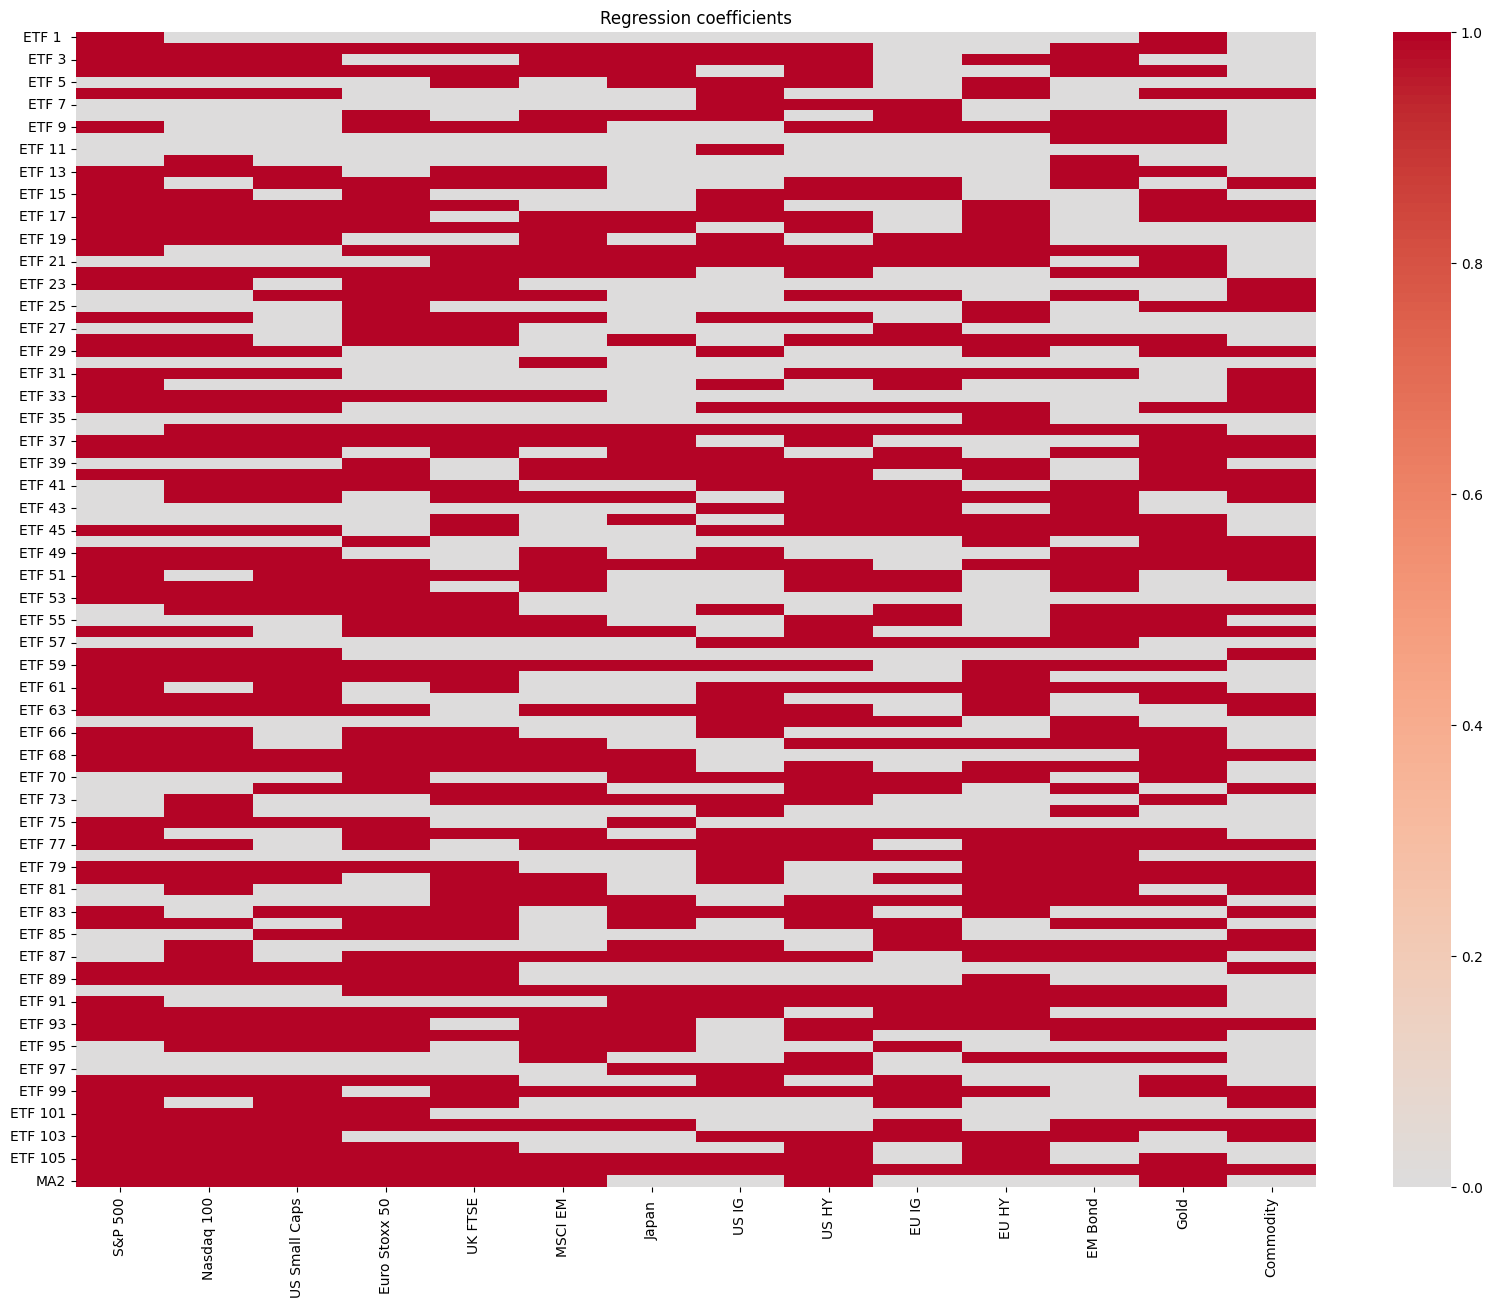

In [51]:
plt.figure(figsize=(20, 15))
sns.heatmap(significance, 
            cmap="coolwarm",     # red/blue diverging colors
            center=0,            # 0 = white midpoint
            annot=False)         # set to True if you want numbers
plt.title("Regression coefficients")
plt.show()

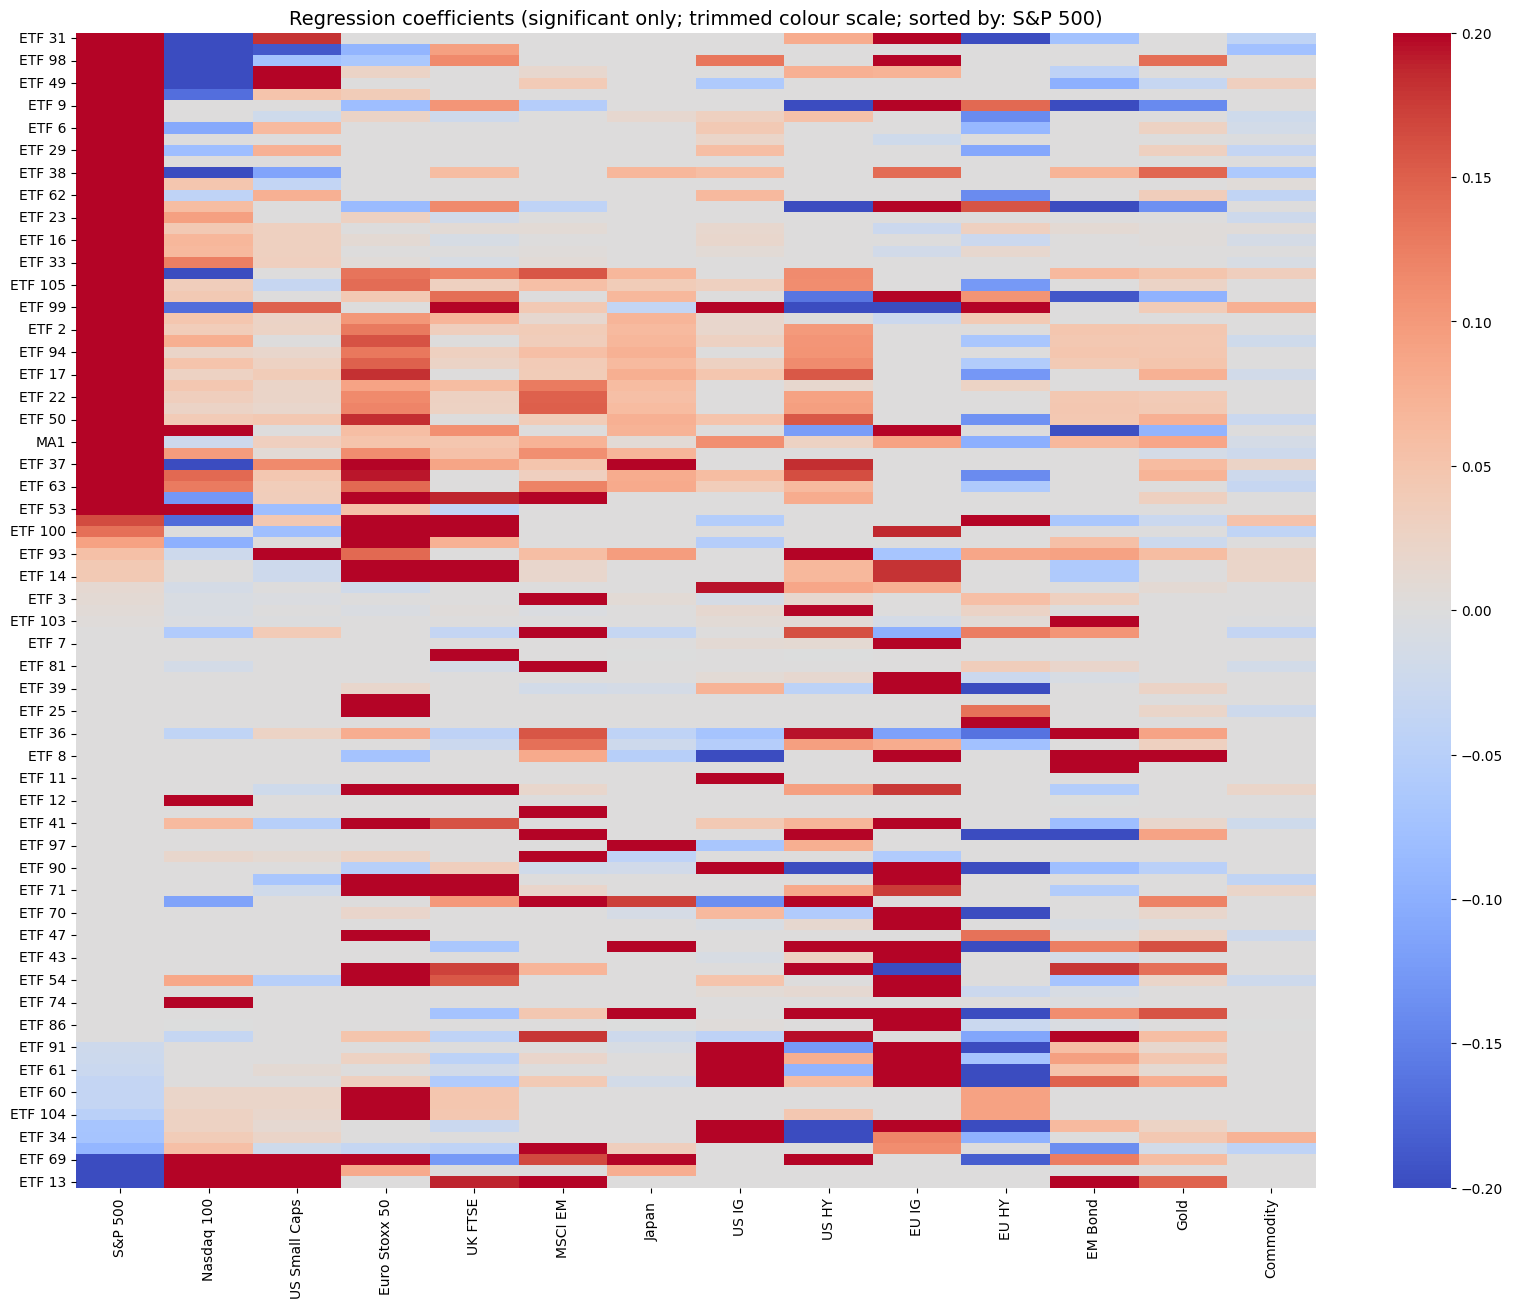

In [52]:
plt.figure(figsize=(20, 15))
sns.heatmap(betas_signif.sort_values(by=['S&P 500'], ascending=False), 
            cmap="coolwarm",     # red/blue diverging colors
            center=0,            # 0 = white midpoint
            annot=False,         # set to True if you want numbers
            vmin=-0.2,
            vmax=0.2)       
plt.title("Regression coefficients (significant only; trimmed colour scale; sorted by: S&P 500)", fontsize=14)
plt.show()

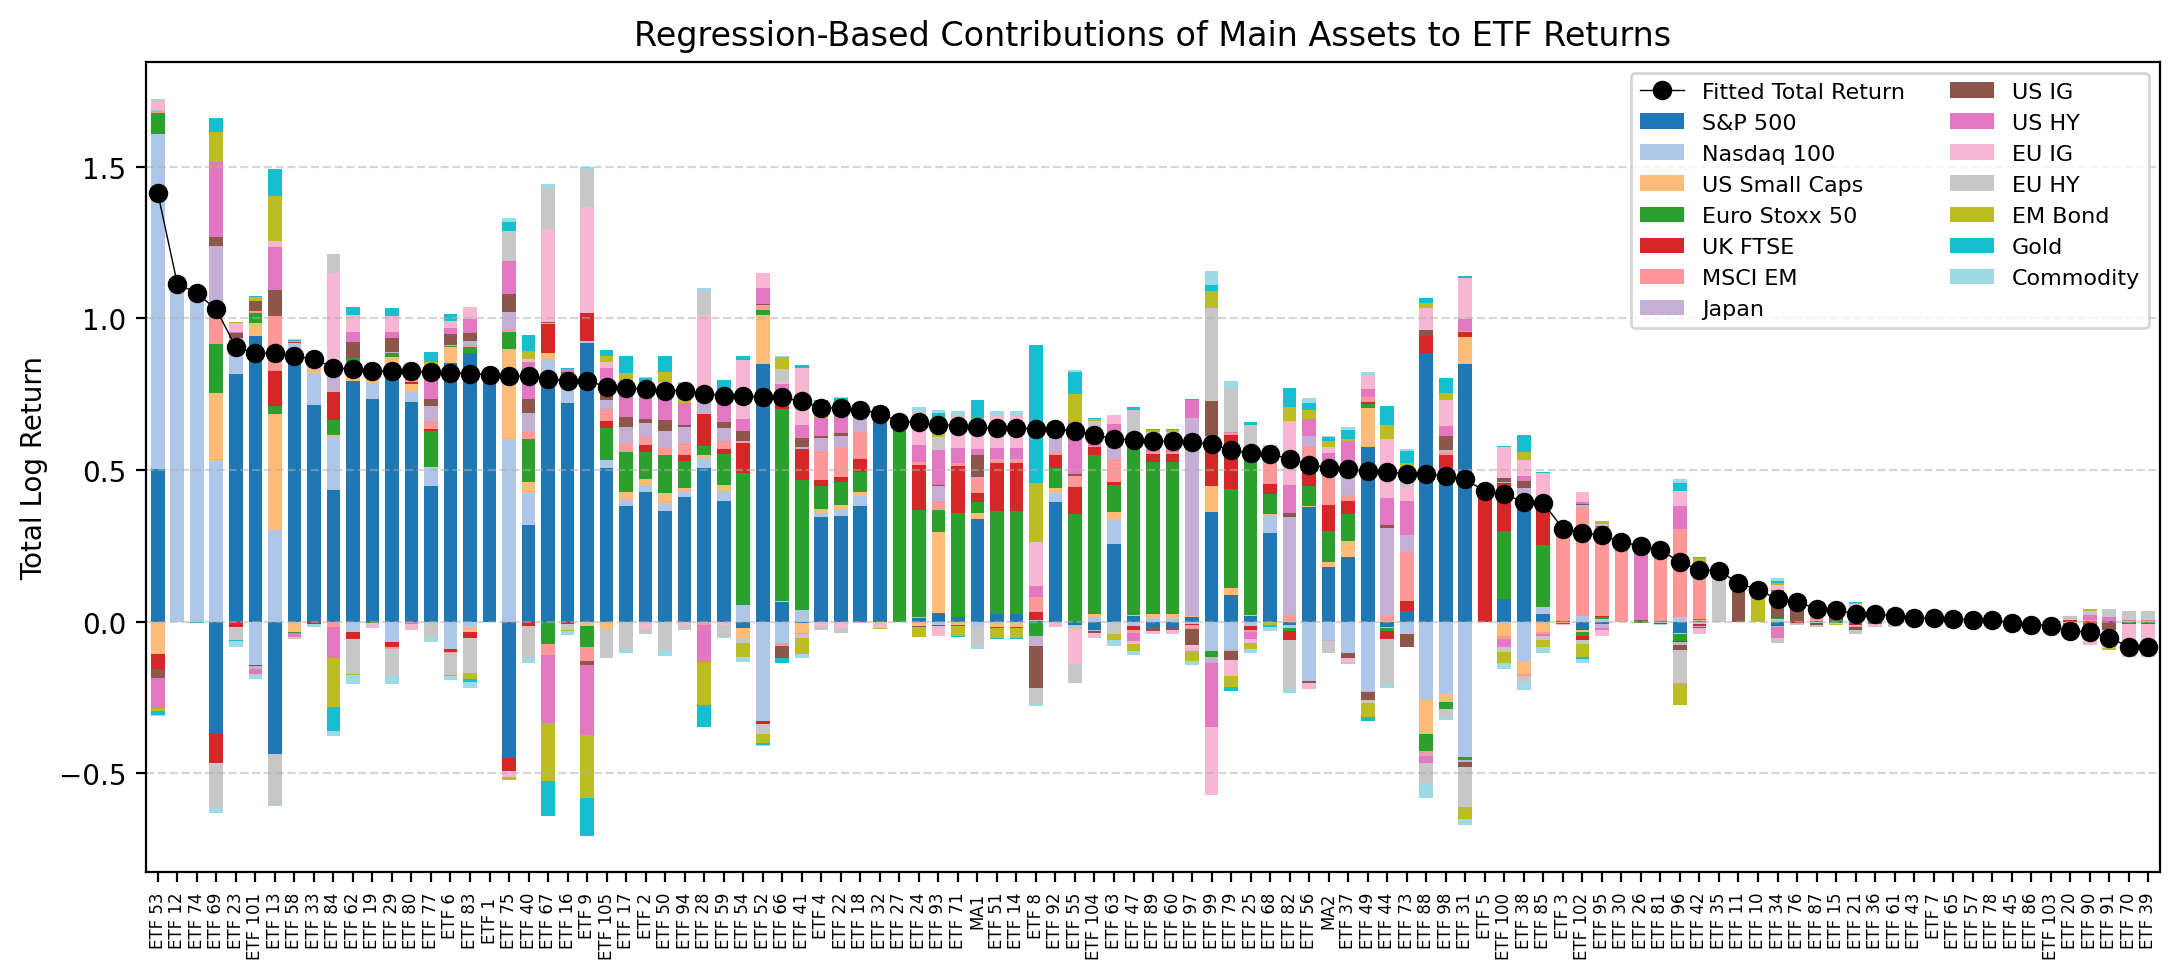

In [53]:
# OLS-based contributions for a stacked barchart
total_returns = (contrib).sum(axis=1)
contrib_sorted = (contrib).loc[total_returns.sort_values(ascending=False).index]

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11,5), dpi=200)

# Stacked bar chart
contrib_sorted.plot(kind='bar', stacked=True, ax=ax, cmap='tab20', width=0.7)

ax.plot(
    np.arange(len(contrib_sorted)),  # x positions
    contrib.sum(axis=1).sort_values(ascending=False),           # y values
    color='black',
    linewidth=0.5,
    marker='o',
    label='Fitted Total Return'
)

# Labels and title
ax.set_ylabel("Total Log Return")
ax.set_title("Regression-Based Contributions of Main Assets to ETF Returns", fontsize=12)
plt.xticks(rotation=90, fontsize=6)

# Grid and legend
ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc = 'upper right', ncol = 2, fontsize=8)

plt.tight_layout()
plt.show()

Principal Component Analysis

PCA LOADING

In [54]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = df_main_lreturns.copy()  
etf_returns = df_lreturns_all.copy()

# Standardize main asset returns
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Run PCA on asset classes
pca = PCA()
factor_returns_scaled = pca.fit_transform(X_scaled)

# Create loadings DataFrame (components)
loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i+1}" for i in range(len(X.columns))]
)

variance explained by PCs

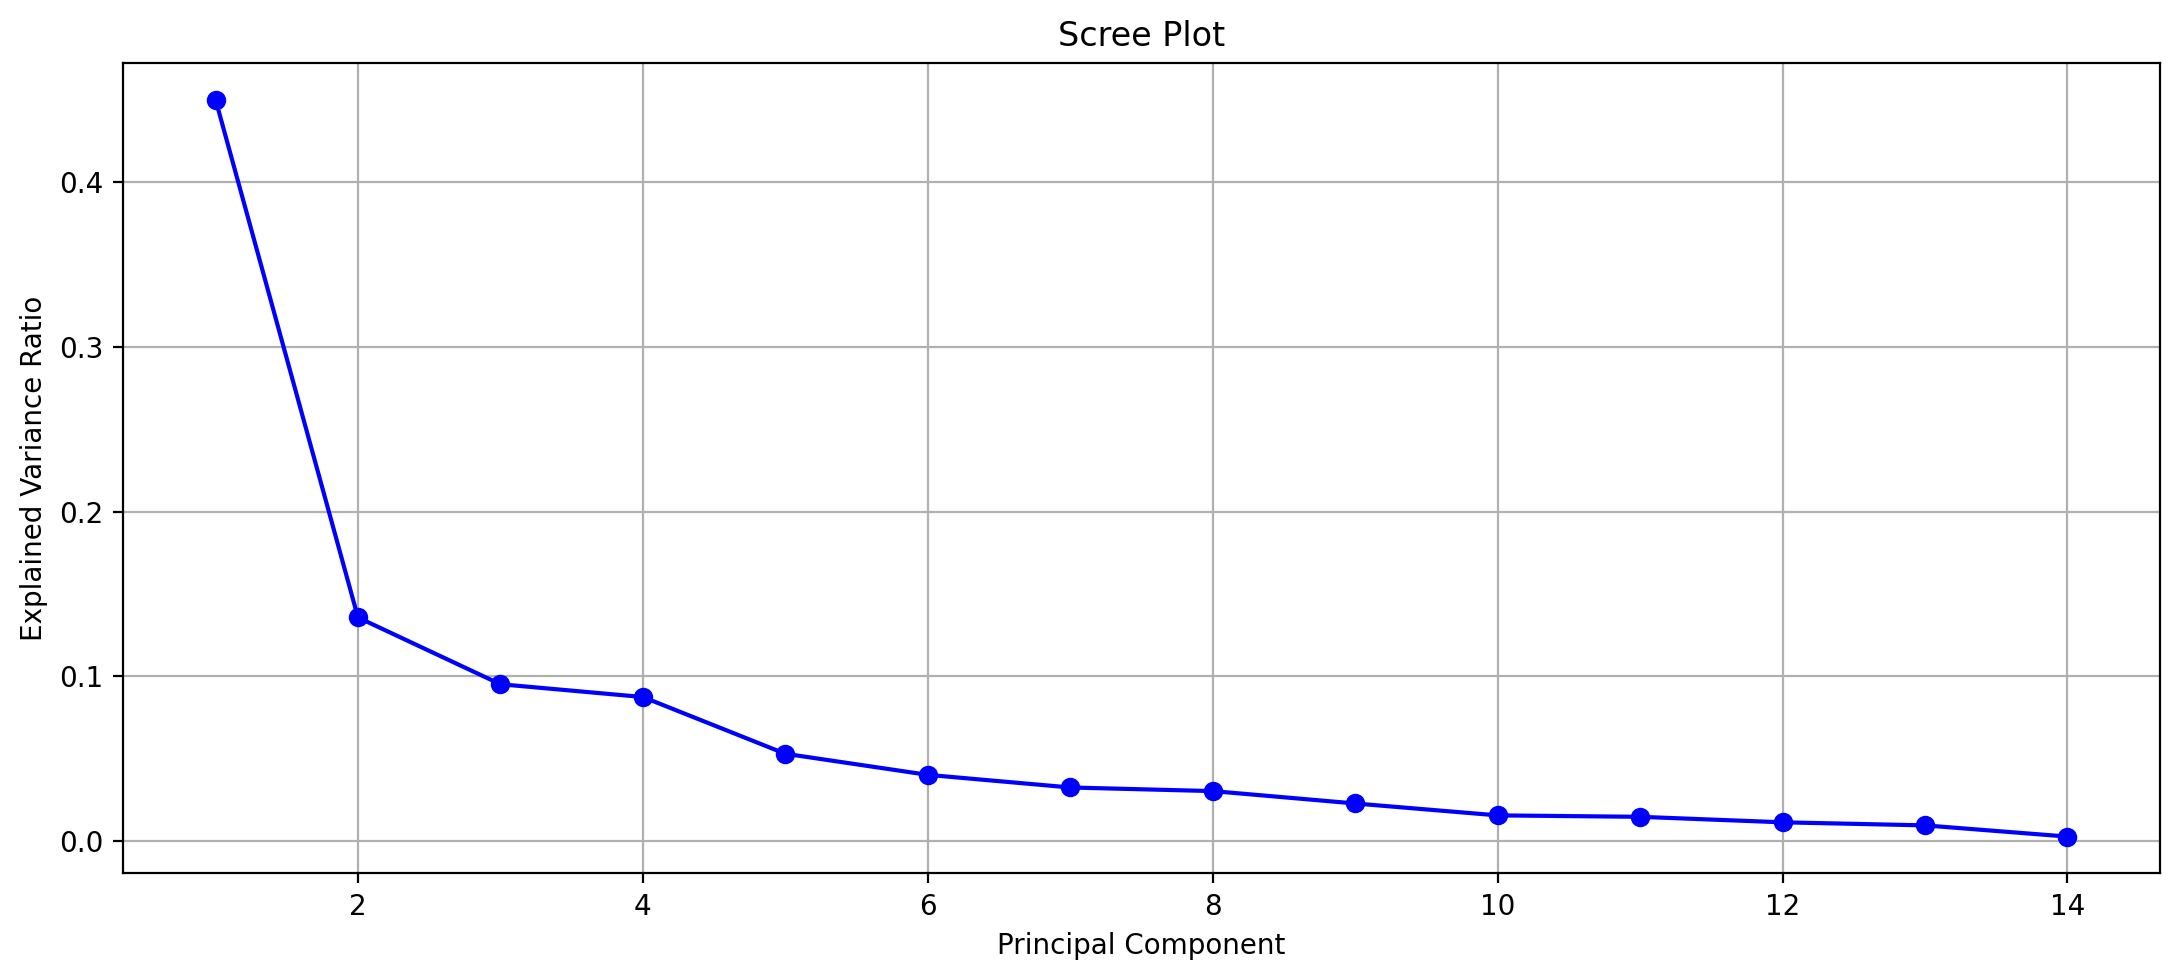

In [55]:
explained_variance = pd.Series(pca.explained_variance_ratio_, index=loadings.index)

plt.figure(figsize=(11,5), dpi=200)
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', c='blue')

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("Scree Plot", fontsize = 12)
plt.grid(True)

plt.tight_layout()
plt.show()

Loadings magnitude chart

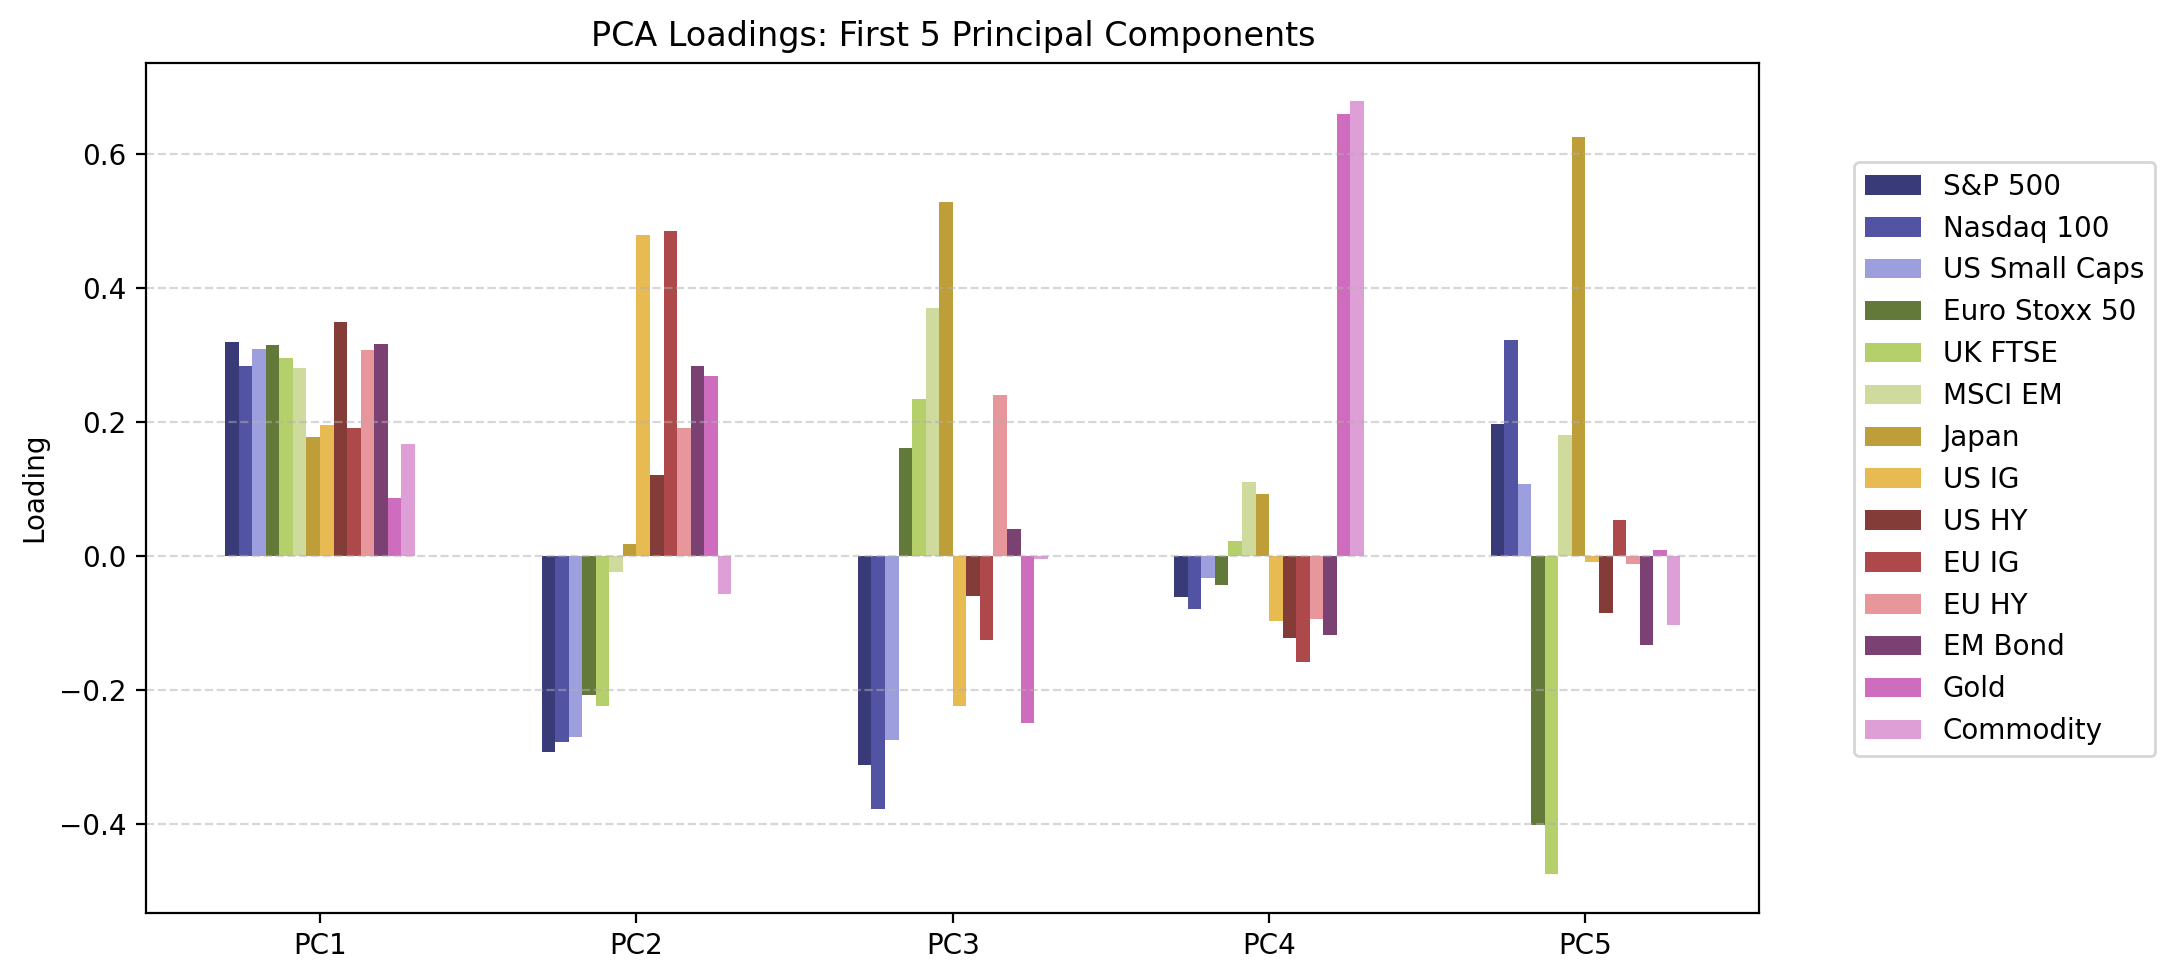

In [56]:
fig, ax = plt.subplots(figsize=(11,5), dpi=200)

# Plot first 5 PCs as bar chart
loadings.iloc[:5, :].plot(kind='bar', ax=ax, width=0.6, cmap='tab20b')

ax.set_ylabel('Loading')
ax.set_title('PCA Loadings: First 5 Principal Components', fontsize = 12)

plt.xticks(rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.5)

ax.legend(bbox_to_anchor=(1.05, 0.9), loc='upper left')

plt.tight_layout()
plt.show()

PCA regression betas

In [57]:
etf_returns = df_lreturns_all.copy()

# Convert factor returns back to real scale
factor_returns_real = X.values @ pca.components_.T
factor_returns_real = pd.DataFrame(
    factor_returns_real,
    index=X.index,
    columns=loadings.index
)

factor_cum = factor_returns_real.cumsum()

top_pcs = ['PC1','PC2','PC3','PC4','PC5']  # choose top 5 PCs

betas_pca = {}

for etf in etf_returns.columns:
    y = etf_returns[etf]
    X_f = sm.add_constant(factor_returns_real[top_pcs])
    model = sm.OLS(y, X_f).fit()
    betas_pca[etf] = model.params

betas_pca = pd.DataFrame(betas_pca).T

Return contributions

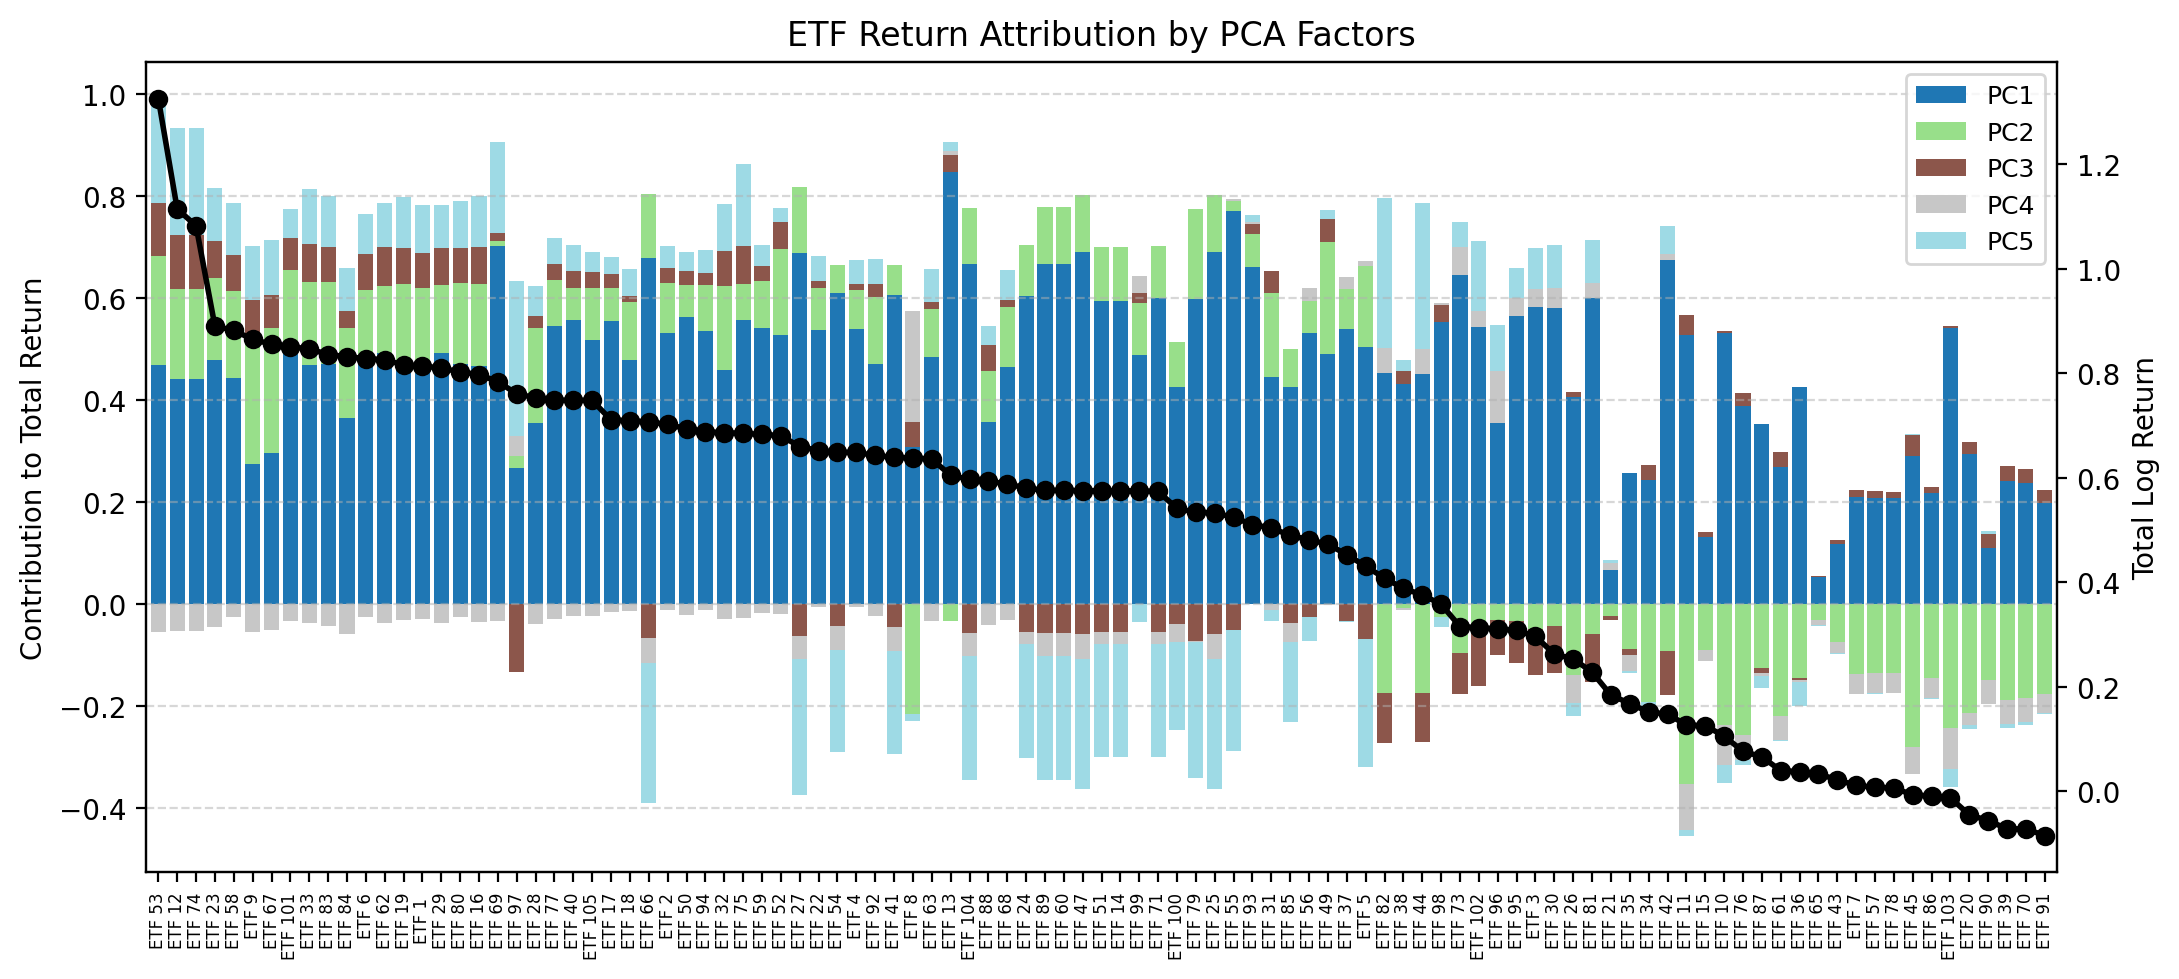

In [58]:
# Total cumulative factor returns
total_factor_return = factor_cum[top_pcs].iloc[-1]  # final value per PC

# Contribution = beta * factor cumulative return
contrib_pca = betas_pca.drop(columns='const').multiply(total_factor_return, axis=1)

# Compute total contribution per ETF and sort
sorted_order = df_lreturns_cum.iloc[-1].sort_values(ascending=False).index
contrib_pca_sorted = contrib_pca.loc[sorted_order]

# Plot
fig, ax = plt.subplots(figsize=(11,5), dpi=200)

contrib_pca_sorted.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    cmap='tab20',
    width=0.8
)

plt.xticks(rotation=90, fontsize=6)

ax2 = ax.twinx()
ax2.plot(
    np.arange(len(sorted_order)),
    df_lreturns_cum.iloc[-1].sort_values(ascending=False).values,
    color='black',
    linewidth=2,
    marker='o',
    label='Total Return'
)

ax.set_title("ETF Return Attribution by PCA Factors", fontsize=12)
ax.set_ylabel("Contribution to Total Return")
ax2.set_ylabel("Total Log Return")

ax.grid(axis='y', linestyle='--', alpha=0.5)
ax.legend(loc='upper right', fontsize=9)


plt.tight_layout()
plt.show()

Asset class identifications

In [59]:
total_returns = df_lreturns_cum.iloc[-1]

top_etfs = total_returns.nlargest(5).index
bot_etfs = total_returns.nsmallest(5).index
middle_etfs = (
    total_returns
    .sort_values()
    .iloc[len(total_returns)//2 - 2 : len(total_returns)//2 + 3]
    .index)
mystery_etfs = ['MA1', 'MA2']

etf_groups = {
    'Top Performing' : top_etfs,
    'Mid Performing' : middle_etfs,
    'Worst Performing' : bot_etfs,
    'Mystery Allocation' : mystery_etfs
}

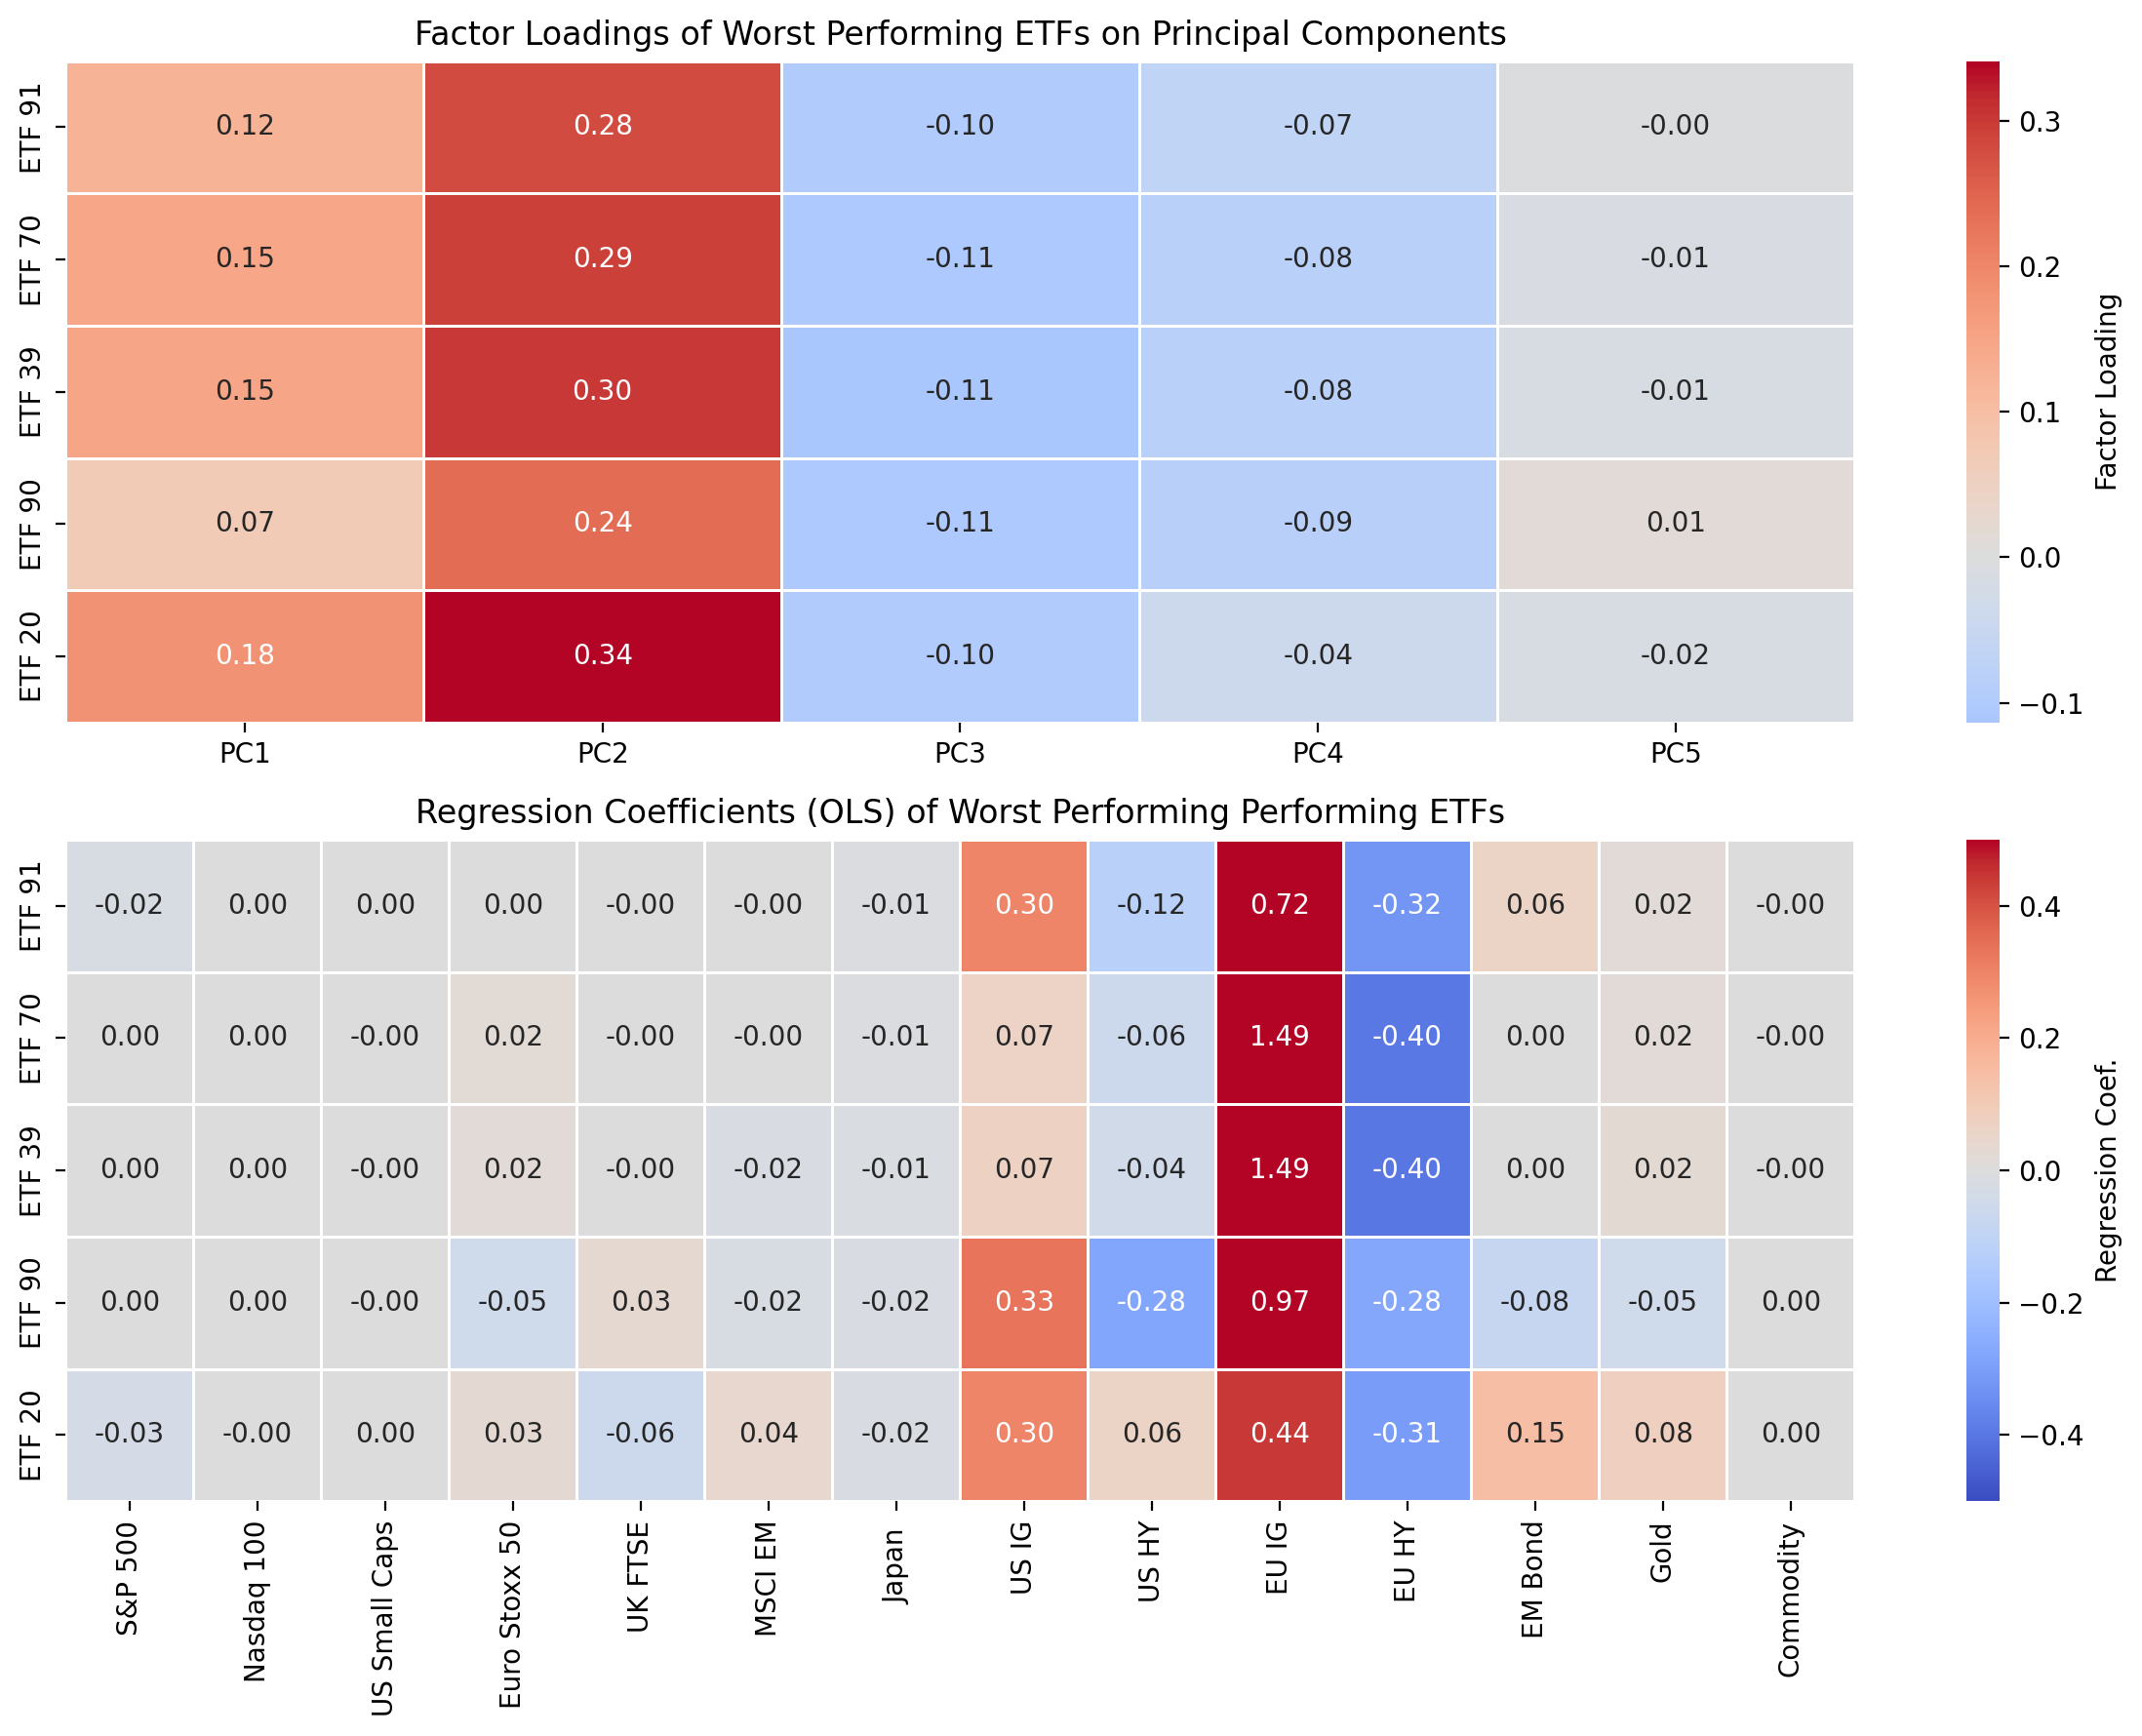

In [60]:
chosen_group = 'Worst Performing' # chose amoung defined above

fig, axes = plt.subplots(2, 1, figsize=(12,9), dpi=200, sharey=True)

sns.heatmap(
    betas_pca[top_pcs].loc[etf_groups[chosen_group]], 
    center=0,                      
    cmap="coolwarm",                
    annot=True,                     
    fmt=".2f",                     
    linewidths=0.5,                
    linecolor='white',             
    cbar_kws={'label': 'Factor Loading'},
    ax=axes[0]
)

axes[0].set_title(f"Factor Loadings of {chosen_group} ETFs on Principal Components", fontsize=12)


sns.heatmap(betas_signif.loc[etf_groups[chosen_group]], 
            cmap="coolwarm",     # red/blue diverging colors
            center=0,            # 0 = white midpoint
            annot=True,
            fmt=".2f",
            linewidths=0.5,
            linecolor='white',
            cbar_kws={'label': 'Regression Coef.'}, 
            vmin=-0.5,
            vmax=0.5,
            ax=axes[1])   

axes[1].set_title(f"Regression Coefficients (OLS) of {chosen_group} Performing ETFs", fontsize=12)

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Mystery allocations

Static

In [61]:
# Inputs
y = df_lreturns_all['MA1'].values
X = df_lreturns.values

n_assets = X.shape[1]

# Optimization variable
w = cp.Variable(n_assets)

# Objective: minimize tracking error
objective = cp.Minimize(cp.sum_squares(y - X @ w))

# Constraints
constraints = [
    w >= 0,
    cp.sum(w) == 1
]

problem = cp.Problem(objective, constraints)
problem.solve()

# Results
weights = pd.Series(w.value, index=df_lreturns.columns)
weights.round(2).abs().sort_values(ascending=False).loc[weights >0.01]

ETF 31     0.20
ETF 40     0.18
ETF 53     0.15
ETF 8      0.10
ETF 11     0.10
ETF 34     0.05
ETF 102    0.05
ETF 10     0.05
ETF 5      0.05
ETF 1      0.04
ETF 47     0.02
dtype: float64

dynamic 

In [62]:
window = 252  # 1 year
assets = df_lreturns
etf = df_lreturns_all['MA2']

weights_rolling = []

dates = assets.index[window:]

for end in range(window, len(assets)):
    X = assets.iloc[end-window:end].values
    y = etf.iloc[end-window:end].values

    w = cp.Variable(X.shape[1])

    prob = cp.Problem(
        cp.Minimize(cp.sum_squares(y - X @ w)),
        [w >= 0, cp.sum(w) == 1]
    )
    prob.solve(solver=cp.OSQP)

    weights_rolling.append(w.value)

weights_rolling = pd.DataFrame(
    weights_rolling,
    index=dates,
    columns=assets.columns
)

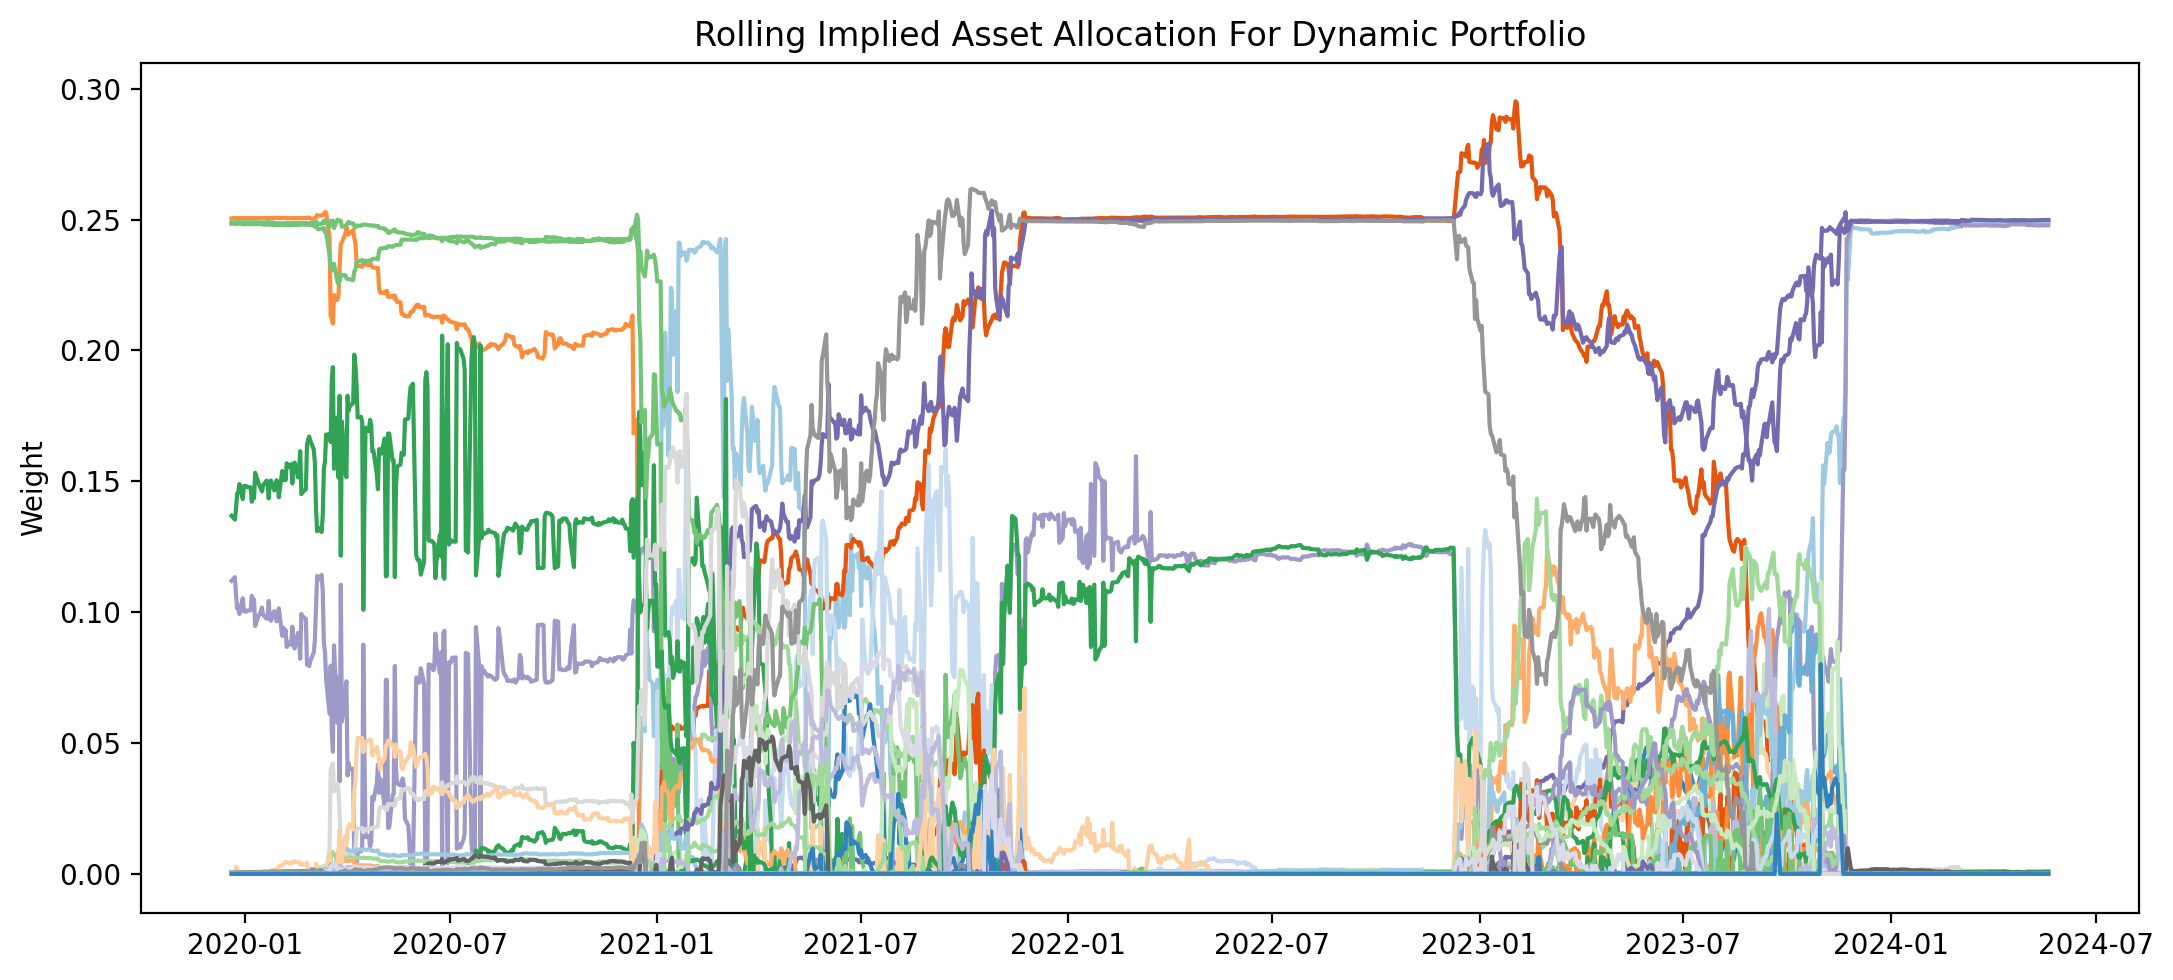

In [63]:
import matplotlib.pyplot as plt

colors = plt.get_cmap('tab20c').colors  # returns 20 RGB tuples

plt.figure(figsize=(11,5), dpi=200)

for i, col in enumerate(weights_rolling.columns):
    plt.plot(weights_rolling.index, weights_rolling[col], label=col, color=colors[i % 20])

plt.title('Rolling Implied Asset Allocation For Dynamic Portfolio', fontsize=12)
plt.ylabel("Weight")
# plt.legend(loc='upper right', ncol=2, fontsize = 8)
plt.tight_layout()
plt.show()

NOICE FILTERING 

Leaders for 2020-03-01 to 2020-10-01: ['ETF 6', 'ETF 14', 'ETF 30', 'ETF 51', 'ETF 52']
Leaders for 2021-09-01 to 2022-09-01: ['ETF 5', 'ETF 14', 'ETF 51', 'ETF 55', 'ETF 102']
Leaders for 2023-06-01 to 2024-05-01: ['ETF 13', 'ETF 23', 'ETF 34', 'ETF 55']


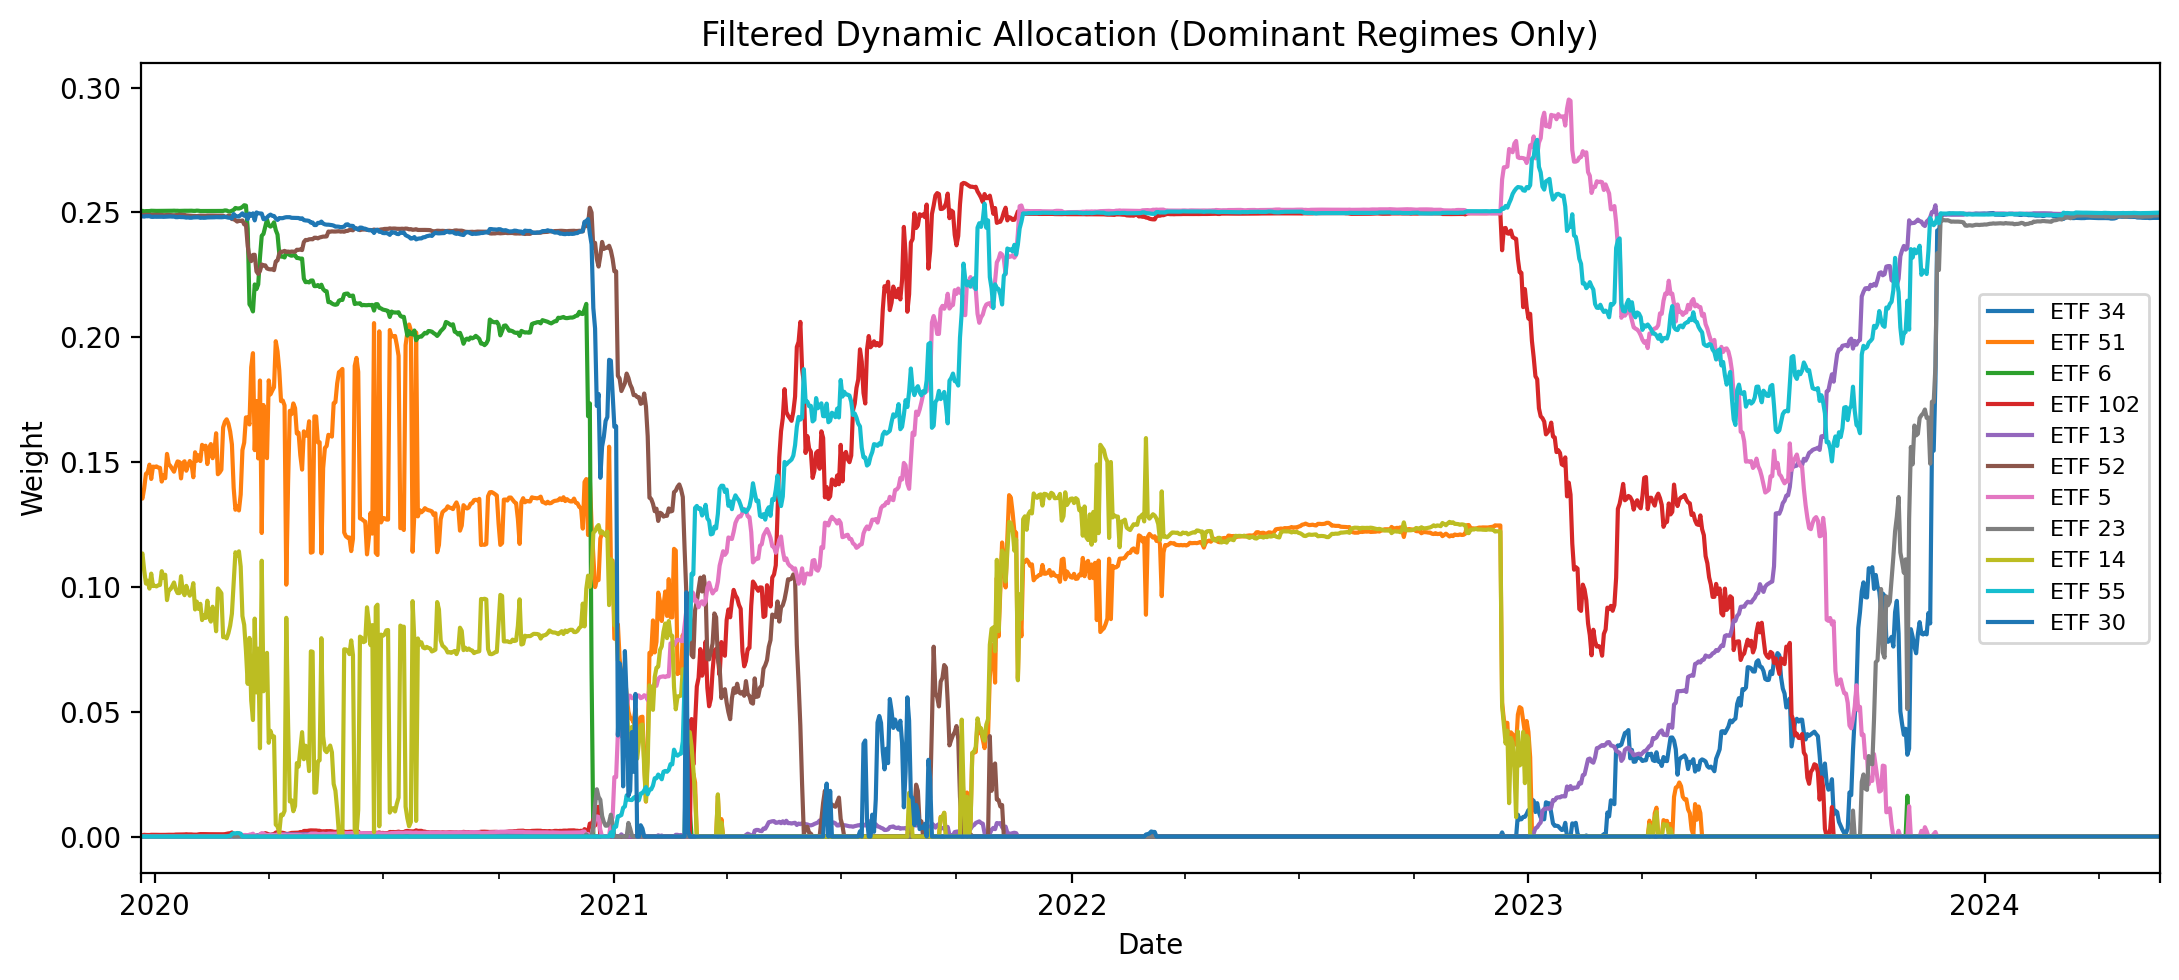


Final Filtered ETF List: ['ETF 34', 'ETF 51', 'ETF 6', 'ETF 102', 'ETF 13', 'ETF 52', 'ETF 5', 'ETF 23', 'ETF 14', 'ETF 55', 'ETF 30']


In [64]:
# 1. Define the approximate "flat" periods based on visual inspection
periods_of_interest = [
    ('2020-03-01', '2020-10-01'),  # Period 1: Greens/Brown/Lavender
    ('2021-09-01', '2022-09-01'),  # Period 2: Lavender/Green/Orange
    ('2023-06-01', '2024-05-01')   # Period 3: Violet/Blue
]

# 2. Identify the Key ETFs
significant_etfs = set()

for start_date, end_date in periods_of_interest:
    # Slice the data for the specific period
    period_data = weights_rolling.loc[start_date:end_date]
    
    # Calculate average allocation in this window
    avg_weights = period_data.mean()
    
    # Select ETFs with > 5% allocation in this period
    leaders = avg_weights[avg_weights > 0.05].index.tolist()
    
    # Add to our master list
    significant_etfs.update(leaders)
    
    print(f"Leaders for {start_date} to {end_date}: {leaders}")

# 3. Filter the Main DataFrame
clean_weights_rolling = weights_rolling[list(significant_etfs)]

# 4. Plot with DPI = 200
# We create the figure and axes explicitly to control DPI
fig, ax = plt.subplots(figsize=(11, 5), dpi=200)

clean_weights_rolling.plot(
    ax=ax,
    title="Filtered Dynamic Allocation (Dominant Regimes Only)"
)

plt.ylabel("Weight")
plt.xlabel("Date")
plt.legend(loc='center right', fontsize=8)
plt.tight_layout() # Adjust layout to prevent clipping of the legend
plt.show()

# 5. Display the final list
print("\nFinal Filtered ETF List:", list(significant_etfs))

fitted allocation

--- FITTED ALLOCATION MODEL ---

Period 1 (2020-03-01 to 2020-10-01):
ETF 51    0.149
ETF 6     0.216
ETF 52    0.240
ETF 14    0.058
ETF 30    0.244

Period 2 (2021-09-01 to 2022-09-01):
ETF 51     0.098
ETF 102    0.250
ETF 5      0.242
ETF 14     0.106
ETF 55     0.241

Period 3 (2023-06-01 to 2024-05-01):
ETF 34    0.150
ETF 13    0.208
ETF 23    0.138
ETF 55    0.218


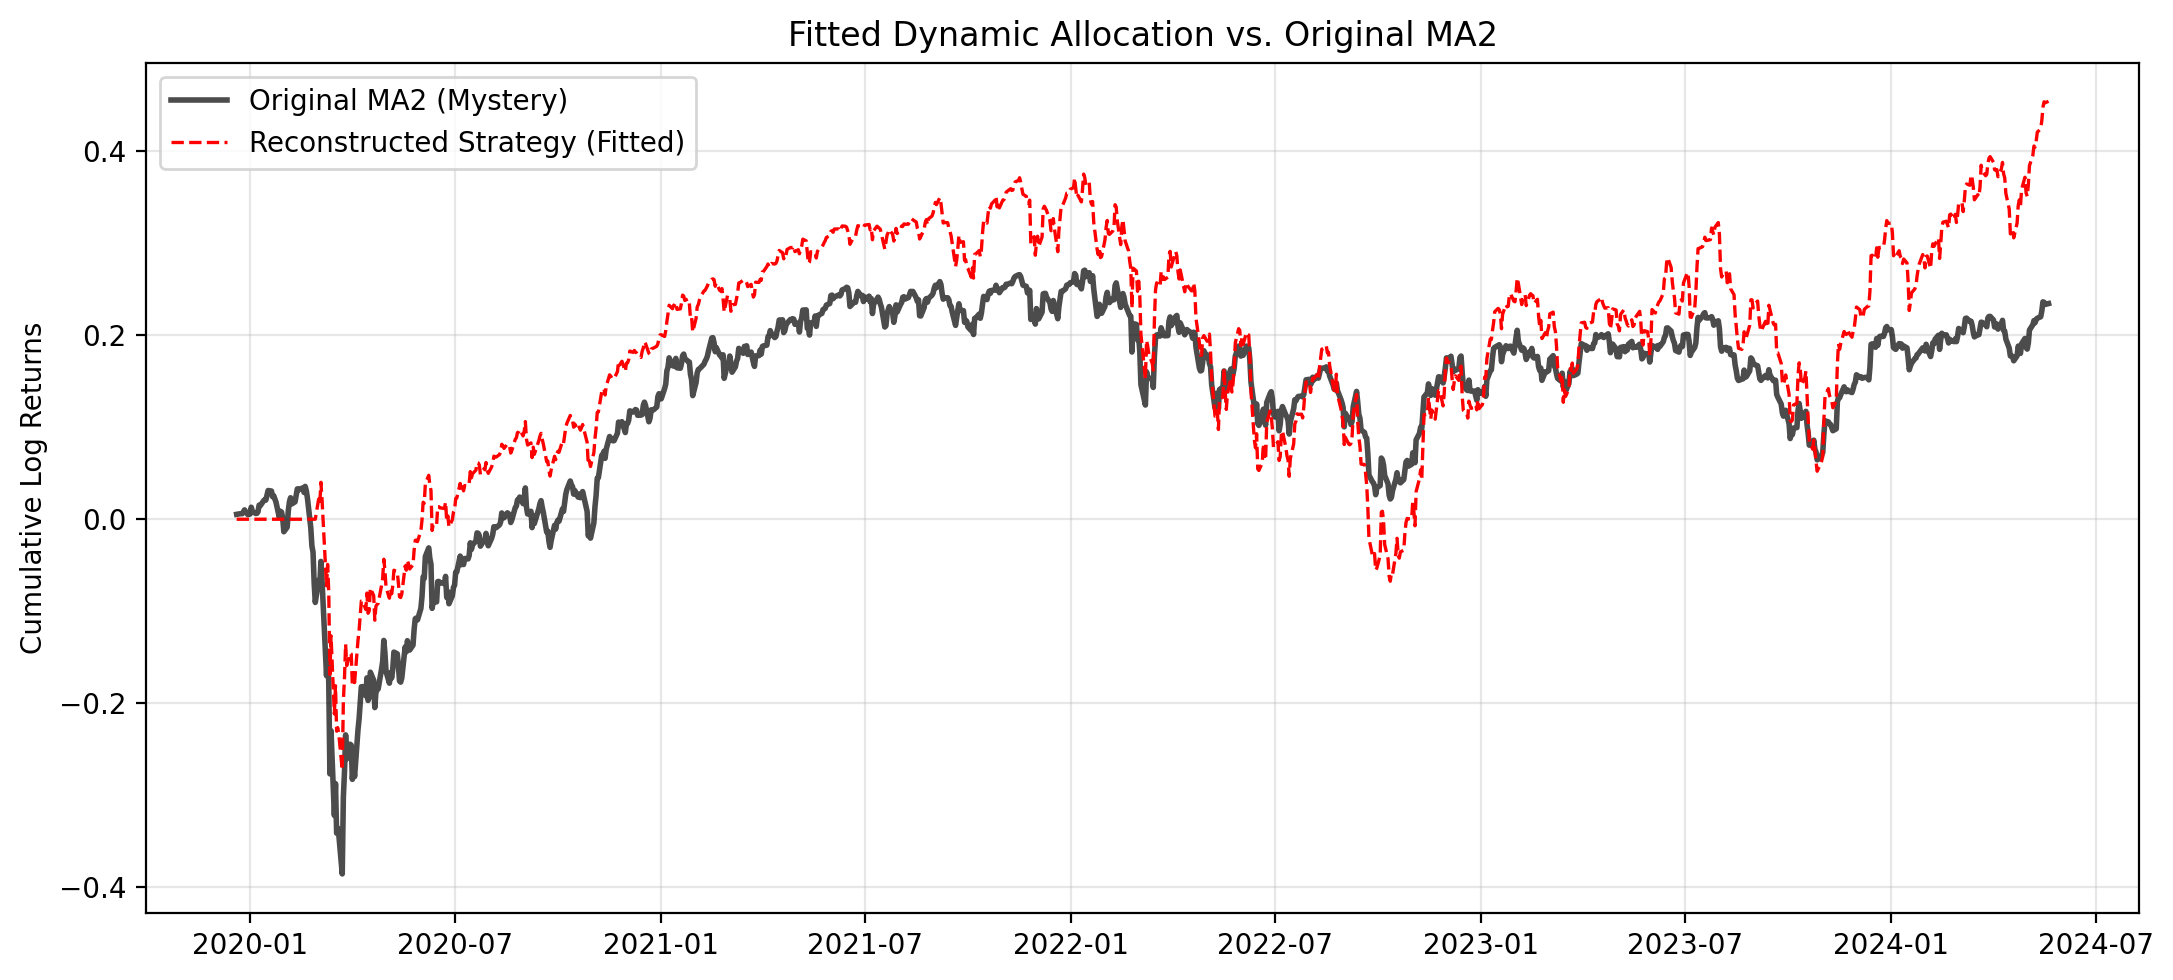

Correlation: 0.8960


In [65]:
# 1. Define the Stable Regimes
# (Adjusted slightly to ensure coverage, but your dates are fine)
periods_of_interest = [
    ('2020-03-01', '2020-10-01'),  
    ('2021-09-01', '2022-09-01'),  
    ('2023-06-01', '2024-05-01')   
]

# 2. Identify the Universe of Dominant ETFs
significant_etfs = set()
for start, end in periods_of_interest:
    period_mean = weights_rolling.loc[start:end].mean()
    significant_etfs.update(period_mean[period_mean > 0.05].index.tolist())

# 3. Create the "Fitted" Series
fitted_allocation = pd.DataFrame(0.0, index=weights_rolling.index, columns=list(significant_etfs))

print("--- FITTED ALLOCATION MODEL ---")

# 4. Fill with Average Weights (THE FIX)
for i, (start, end) in enumerate(periods_of_interest):
    # Get actual data for this window
    period_data = weights_rolling.loc[start:end, list(significant_etfs)]
    
    # Calculate the average weight
    avg_weights = period_data.mean()
    active_weights = avg_weights[avg_weights > 0.05]
    
    # --- FIX START: Assign column by column to avoid broadcasting errors ---
    for etf, weight in active_weights.items():
        fitted_allocation.loc[start:end, etf] = weight
    # --- FIX END ---
        
    print(f"\nPeriod {i+1} ({start} to {end}):")
    print(active_weights.round(3).to_string())

# 5. Fill Gaps (Optional but Recommended)
# The fitted_allocation currently has 0.0s between your periods (e.g. late 2020 to late 2021).
# Forward filling assumes the strategy stays static until the next regime change.
fitted_allocation = fitted_allocation.replace(0.0, pd.NA).ffill().fillna(0.0)

# ---------------------------------------------------------
# CALCULATION PART
# ---------------------------------------------------------

# Align dates
aligned_assets = df_lreturns.loc[fitted_allocation.index]
aligned_ma2 = df_lreturns_all.loc[fitted_allocation.index, 'MA2']

# Calculate Reconstructed Returns
# Using .sum(min_count=1) prevents 0s if data is missing, but normal sum is fine here
reconstructed_returns = (fitted_allocation * aligned_assets).sum(axis=1)

# Calculate Cumulative Performance
cum_reconstructed = reconstructed_returns.cumsum()
cum_ma2 = aligned_ma2.cumsum()

# Plot Comparison
fig, ax = plt.subplots(figsize=(11, 5), dpi=200)
ax.plot(cum_ma2.index, cum_ma2, label='Original MA2 (Mystery)', color='black', linewidth=2, alpha=0.7)
ax.plot(cum_reconstructed.index, cum_reconstructed, label='Reconstructed Strategy (Fitted)', color='red', linestyle='--', linewidth=1.2)

ax.set_title('Fitted Dynamic Allocation vs. Original MA2')
ax.set_ylabel('Cumulative Log Returns')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Correlation
print(f"Correlation: {reconstructed_returns.corr(aligned_ma2):.4f}")

goodness of fit measures 

In [66]:
from sklearn.metrics import r2_score, mean_squared_error

# ---------------------------------------------------------
# 1. Define Metrics Function
# ---------------------------------------------------------
def get_fit_metrics(true_returns, model_returns, model_name):
    # Align data to be safe
    common_idx = true_returns.index.intersection(model_returns.index)
    true_s = true_returns.loc[common_idx]
    model_s = model_returns.loc[common_idx]
    
    # Calculate Residuals (Tracking Difference)
    residuals = true_s - model_s
    
    # 1. Correlation
    corr = true_s.corr(model_s)
    
    # 2. R-Squared (Goodness of Fit)
    r2 = r2_score(true_s, model_s)
    
    # 3. RMSE (Root Mean Squared Error) - annualized (approx * sqrt(252) for scale)
    rmse = np.sqrt(mean_squared_error(true_s, model_s)) * np.sqrt(252)
    
    # 4. Annualized Tracking Error (Std Dev of residuals)
    te = residuals.std() * np.sqrt(252)
    
    return {
        "Model": model_name,
        "Correlation": round(corr, 4),
        "R-Squared": round(r2, 4),
        "RMSE (Ann.)": round(rmse, 4),
        "Tracking Error (Ann.)": round(te, 4)
    }

# ---------------------------------------------------------
# 2. Prepare Data
# ---------------------------------------------------------
# A. STATIC MODEL (MA1)
# Re-calculating static returns based on your 'weights' variable from earlier
# (Assuming 'weights' is the Series you created in section 6.0)
# If 'weights' isn't in memory, replace with your filtered top static weights
static_model_returns = (df_lreturns.values @ weights.values) 
# Note: Ensure shapes align. If df_lreturns is (T, N) and weights is (N,), this works.
# Make it a Series for easier handling
static_model_series = pd.Series(static_model_returns, index=df_lreturns.index)
ma1_true_series = df_lreturns_all['MA1']

# B. DYNAMIC MODEL (MA2) - using your new 'reconstructed_returns'
# (Assuming you just ran the fixed code and have 'reconstructed_returns')
dynamic_model_series = reconstructed_returns
ma2_true_series = aligned_ma2

# ---------------------------------------------------------
# 3. Calculate & Display
# ---------------------------------------------------------
metrics_list = []

# Calculate Static
metrics_list.append(get_fit_metrics(ma1_true_series, static_model_series, "Static (MA1)"))

# Calculate Dynamic
metrics_list.append(get_fit_metrics(ma2_true_series, dynamic_model_series, "Dynamic (MA2)"))

# Create DataFrame
df_metrics = pd.DataFrame(metrics_list)

# Display
print(df_metrics.to_string(index=False))

# Optional: Interpret the results
print("\n--- Interpretation ---")
print("High R² (>0.8) and Correlation (>0.9) indicate the reconstructed strategy is structurally identical.")
print("Low Tracking Error (<0.05) implies the 'noise' we filtered out contributed very little to risk.")

        Model  Correlation  R-Squared  RMSE (Ann.)  Tracking Error (Ann.)
 Static (MA1)        1.000     0.9999       0.0011                 0.0010
Dynamic (MA2)        0.896     0.7115       0.0941                 0.0941

--- Interpretation ---
High R² (>0.8) and Correlation (>0.9) indicate the reconstructed strategy is structurally identical.
Low Tracking Error (<0.05) implies the 'noise' we filtered out contributed very little to risk.
